# Atividade: Classificação de Grãos

## Dataset
Para esta tarefa, utilizaremos uma versão adaptada do Dry Bean Dataset, disponível no arquivo `beans_train.csv`. O conjunto é composto por amostras de diferentes tipos de feijões secos, descritas por atributos morfológicos extraídos a partir de imagens, como área, perímetro, compacidade, excentricidade e fatores de forma. Essas características capturam propriedades geométricas relevantes dos grãos, permitindo distinguir classes com base em padrões estruturais no espaço de atributos.

As amostras estão organizadas em sete classes distintas de feijões: Seker, Barbunya, Bombay, Cali, Dermason, Horoz e Sira.

## O que será avaliado
Serão considerados os seguintes aspectos:

* **Implementação:** Coerência entre o problema proposto e o método de classificação adotado, bem como a correta aplicação do algoritmo.
* **Estabilidade:** Controle do comportamento do processo de treinamento, assegurando convergência consistente e reduzindo variações indesejadas ao longo da otimização.
* **Regularização:** Capacidade de mitigar o sobreajuste por meio de estratégias adequadas ao modelo e aos dados.
* **Análise de Desempenho:** Interpretação dos resultados com base em métricas apropriadas de avaliação.

## Entrega
A atividade deve ser entregue obrigatoriamente em formato de **Jupyter Notebook (.ipynb)**. O arquivo deve estar devidamente organizado e comentado, justificando as decisões tomadas para garantir a estabilidade e a capacidade de generalização do modelo.


# Desenvolvimento da Atividade

## Investigação preliminar dos dados


Nessa investigação buscamos compreender de forma básica as características dos dados do dataset beans_train.csv.
Para isso vamos ler o dataset num dataframe pandas e levantar algumas estatisticas. Em função disso vamos determinar os passo necessários de pre-processamento que serão utilizados.

In [1]:
import torch
import pandas as pd

df = pd.read_csv('beans_train.csv')

# Seleciona o dispositivo com prioridade: CUDA > MPS > CPU
device = torch.device(
    'cuda' if torch.cuda.is_available() # GPU
    else 'mps' if torch.backends.mps.is_available() # MPS (Mac Silicon)
    else 'cpu' # CPU
)
print(f"Usando o dispositivo: {device}")

Usando o dispositivo: mps


### Visualizando as primeiras 10 linhas

In [2]:
df.head(10)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,38465.705594,737.090445,273.111968,179.201525,1.523333,0.753998,38999.014066,220.991553,0.813252,0.988670,0.888416,0.809359,0.007117,0.001879,0.655710,0.996874,SIRA
1,70247.179155,1019.740591,376.308440,238.192942,1.582115,0.773556,71562.831696,299.139162,0.707757,0.985750,0.850248,0.794947,0.005351,0.001324,0.632118,0.998320,BARBUNYA
2,74212.949558,1049.756998,414.858346,229.655950,1.810139,0.834413,75004.806409,306.719019,0.776048,0.987679,0.844313,0.739884,0.005597,0.001039,0.548725,0.991096,CALI
3,31233.029736,671.584675,257.751304,154.448259,1.670969,0.800540,31682.423625,198.813755,0.718182,0.988299,0.870828,0.773574,0.008257,0.001822,0.598230,0.996528,DERMASON
4,48189.750788,826.752018,313.328739,196.497443,1.604009,0.781591,48840.530648,247.963648,0.796755,0.988498,0.887039,0.788613,0.006525,0.001556,0.622442,0.995508,SIRA
5,57356.907479,958.191465,400.523353,182.796156,2.186816,0.889473,57860.551234,269.985000,0.569907,0.988100,0.782668,0.673195,0.007018,0.000892,0.453699,0.992911,HOROZ
6,32171.814046,659.848322,239.925576,171.207725,1.408751,0.704095,32773.991337,203.133528,0.732065,0.986681,0.926887,0.842839,0.007454,0.002320,0.708291,0.997717,DERMASON
7,54115.074552,855.886477,286.734712,242.350112,1.180368,0.531732,54686.273502,262.825642,0.788499,0.990122,0.933415,0.919372,0.005270,0.002320,0.845115,0.997845,SEKER
8,77259.272204,1096.973650,385.738417,256.126058,1.508870,0.748752,78685.329186,314.300183,0.773244,0.983759,0.809262,0.812457,0.004993,0.001348,0.658929,0.995432,BARBUNYA
9,36349.710092,689.671173,242.197615,190.452403,1.270238,0.616005,36493.668120,214.491109,0.776832,0.990745,0.952517,0.886411,0.006695,0.002553,0.786668,0.998273,SEKER


### Calculando a distribuição das featureas: médias, desvio padrão, percentis, máximos e mínimos

In [3]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000
mean,52984.826554,854.735445,319.900759,202.160613,1.582773,0.750914,53707.155435,252.908484,0.749728,0.987122,0.873351,0.799940,0.006567,0.001718,0.643693,0.995069
std,29295.457791,214.444640,85.691172,44.964220,0.245892,0.091630,29749.674675,59.182734,0.048963,0.004668,0.059242,0.061495,0.001130,0.000596,0.098626,0.004390
min,20345.408013,524.528134,183.312292,122.327171,1.026275,0.218787,20684.208989,161.412105,0.555519,0.943587,0.571799,0.645318,0.002777,0.000568,0.416878,0.950032
25%,36287.942022,702.783268,253.116922,175.613608,1.433148,0.716372,36637.411296,214.876017,0.718193,0.985636,0.832720,0.762659,0.005905,0.001155,0.581743,0.993741
50%,44534.203579,794.101721,296.618790,192.380899,1.549896,0.764116,45050.873268,238.145830,0.759660,0.988270,0.883286,0.801594,0.006648,0.001700,0.642496,0.996399
75%,61301.065303,976.352085,376.380761,216.986950,1.706149,0.810119,62219.957215,279.298556,0.786905,0.989989,0.916905,0.834040,0.007280,0.002173,0.695535,0.997896
max,254495.210567,1987.238396,738.618173,460.043477,2.389710,0.908263,263278.394353,569.109998,0.866303,0.994666,0.990888,0.987507,0.010451,0.003664,0.975513,0.999727


### Encontrando as features com maior e menor média e desvio padrão

In [4]:
def explore_dataset(s):
  '''
  Retorna o índice e o valor mínimo e máximo de um série
  '''
  return s.idxmin(), s.min(), s.idxmax(), s.max()

numeric_df = df.drop(columns=['Class'])
# médias de cada atributo numérico
means = numeric_df.mean()

# mínimo e máximo entre as médias
min_means_attr, min_means_value, max_means_attr, max_means_value = explore_dataset(means)

# desvios padrão de cada atributo numérico
deviations = numeric_df.std()
min_deviations_attr, min_deviations_value, max_deviations_attr, max_deviations_value = explore_dataset(deviations)

print(f"Menor média........: {min_means_attr} = {min_means_value:.4f}")
print(f"Menor desvio padrão: {min_deviations_attr} = {min_deviations_value:.6f}")
print( "Atributo com a menor média é igual ao atributo com o menor desvio padrão" if min_means_attr == min_deviations_attr 
      else "Atributo com a menor média e atributo com o menor desvio padrão são diferentes")
print()
print(f"Maior média........: {max_means_attr} = {max_means_value:.2f}")
print(f"Maior desvio padrão: {max_deviations_attr} = {max_deviations_value:.2f}")
print( "Atributo com a maior média é igual ao atributo com o maior desvio padrão" if max_means_attr == max_deviations_attr 
      else "Atributo com a maior média e atributo com o maior desvio padrão são diferentes")

Menor média........: ShapeFactor2 = 0.0017
Menor desvio padrão: ShapeFactor2 = 0.000596
Atributo com a menor média é igual ao atributo com o menor desvio padrão

Maior média........: ConvexArea = 53707.16
Maior desvio padrão: ConvexArea = 29749.67
Atributo com a maior média é igual ao atributo com o maior desvio padrão


In [5]:
df.info()
print(f"O dataset possui {df.shape[0]} amostras e {df.shape[1]} atributos: shape {df.shape}")

<class 'pandas.DataFrame'>
RangeIndex: 10888 entries, 0 to 10887
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             10888 non-null  float64
 1   Perimeter        10888 non-null  float64
 2   MajorAxisLength  10888 non-null  float64
 3   MinorAxisLength  10888 non-null  float64
 4   AspectRation     10888 non-null  float64
 5   Eccentricity     10888 non-null  float64
 6   ConvexArea       10888 non-null  float64
 7   EquivDiameter    10888 non-null  float64
 8   Extent           10888 non-null  float64
 9   Solidity         10888 non-null  float64
 10  roundness        10888 non-null  float64
 11  Compactness      10888 non-null  float64
 12  ShapeFactor1     10888 non-null  float64
 13  ShapeFactor2     10888 non-null  float64
 14  ShapeFactor3     10888 non-null  float64
 15  ShapeFactor4     10888 non-null  float64
 16  Class            10888 non-null  str    
dtypes: float64(16), str(1)


### Observações importantes

A partir da exploração inicial do dataset, destacam-se os seguintes pontos:

1. O conjunto de dados possui 10888 amostras, com 16 atributos (features) e 1 variável de classe, totalizando 17 colunas (shape: 10888 × 17).
2. Não foram identificados valores nulos em nenhuma das colunas, não sendo necessária, portanto, uma etapa de limpeza preliminar.
3. Todos os 16 atributos são numéricos, do tipo *float64*, eliminando a necessidade de pré-processamento para codificação de variáveis não numéricas.
4. Observa-se uma diferença significativa de escala entre os atributos; a feature com menor média e desvio padrão (ShapeFactor2) apresenta $\mu=0.0017$ e $\sigma=0.000596$, enquanto a feature com maior média e desvio padrão (ConvexArea) apresenta $\mu=53707.16$ e $\sigma=29749.67$.

Diante desse cenário, evidencia-se a necessidade de normalização dos dados de entrada, a fim de mitigar o viés decorrente das diferenças de escala entre os atributos.

*IMPORTANTE:* Por questões metodológicas, os dados devem ser particionados em conjuntos de treino, validação e teste. Os parâmetros de normalização (média $\mu$ e desvio padrão $\sigma$) serão estimados exclusivamente a partir do conjunto de treino e, em seguida, aplicados de forma consistente aos conjuntos de validação e teste. Esse procedimento busca evitar o vazamento de informação (*data leakage*) e garantir a comparabilidade entre os conjuntos durante o processo de treinamento e avaliação dos modelos.

## Metodologia

Em função da investigação preliminar realizada, decidimos adotar a seguinte metodologia experimental para este trabalho:

1. **Pré-processamento:** os dados são particionados em conjunto de desenvolvimento (90%) e conjunto de teste (10%), preservando-se a distribuição das classes por meio de amostragem estratificada. O conjunto de desenvolvimento será utilizado nas etapas de seleção de hiperparâmetros e treinamento dos modelos, enquanto o conjunto de teste permanecerá isolado para avaliação final.

2. **Normalização dos dados:** os atributos são padronizados por meio de normalização do tipo Z-score. Em todas as etapas do experimento, os parâmetros de normalização (média e desvio padrão) são estimados exclusivamente sobre os dados de treino de cada partição e posteriormente aplicados aos respectivos subconjuntos de validação. Esse procedimento é adotado tanto na etapa de holdout quanto na validação cruzada, evitando vazamento de informação (*data leakage*) entre os conjuntos.

3. **Busca de hiperparâmetros:** define-se um espaço de busca contendo diferentes configurações de hiperparâmetros das MLPs, incluindo número de camadas, quantidade de neurônios, funções de ativação, algoritmos de otimização, taxas de aprendizado, entre outras. A exploração desse espaço é realizada por meio de uma estratégia holdout aplicada ao conjunto de desenvolvimento, utilizando uma fração de 10% para validação. Ao final dessa etapa, são selecionadas as N configurações mais promissoras com base no desempenho obtido, N a ser definido posteriormente com base nos experimentos, mas garantindo $N \ge 3$

4. **Treinamento dos modelos:** as N configurações selecionadas são avaliadas por meio de validação cruzada estratificada com k=10 partições (StratifiedKFold), utilizando todo o conjunto de desenvolvimento. Para cada partição, o modelo é treinado e avaliado, permitindo obter estimativas mais robustas e menos sensíveis à variabilidade dos dados.

5. **Comparação estatística:** os resultados obtidos ao longo das partições são utilizados para comparar os modelos, possibilitando a aplicação de testes estatísticos e a seleção da configuração final.

6. **Avaliação final:** o modelo selecionado é retreinado utilizando todo o conjunto de desenvolvimento e avaliado no conjunto de teste, previamente mantido isolado, a fim de obter uma estimativa imparcial de desempenho.

De forma geral, adota-se a acurácia como métrica principal de avaliação. Adicionalmente, o F1-score macro e ponderado são utilizados como métricas complementares para análise dos resultados.

## Pré-processamento

### Particionando os dados

Vamos particionar os dados nos conjuntos de treino+validação (90%) e teste (10%), mantendo a estratificação das espécies para preservar a representatividade dos dados. Salvamos os dados localmente para, em necessidade de executar o notebook novamente, os resultados sejam obtidos a partir de um mesmo split.

In [6]:
import os
import json
from sklearn.model_selection import train_test_split

SEED = 42
SPLIT_FILE = "data_split.json"

X = df.drop(columns=['Class'])
y = df['Class']

# ===============================
# Se já existe split salvo
# ===============================
if os.path.exists(SPLIT_FILE):
    with open(SPLIT_FILE, "r") as f:
        split = json.load(f)

    train_idx = split["train_idx"]
    test_idx  = split["test_idx"]

    X_train = X.loc[train_idx]
    y_train = y.loc[train_idx]
    X_test  = X.loc[test_idx]
    y_test  = y.loc[test_idx]

    print("Split carregado do disco")

# ===============================
# Caso contrário cria e salva
# ===============================
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.1,
        stratify=y,
        random_state=SEED
    )

    split = {
        "train_idx": X_train.index.tolist(),
        "test_idx": X_test.index.tolist()
    }

    with open(SPLIT_FILE, "w") as f:
        json.dump(split, f)

    print("Split criado e salvo")

print(f"len(X_train)={len(X_train)}, len(X_test)={len(X_test)}")

Split carregado do disco
len(X_train)=9799, len(X_test)=1089


#### Conferindo a estratificação das espécies

A estratégia de amostragem estratificada preservou a distribuição das classes entre os conjuntos de treino+validação e teste, apresentando variações desprezíveis decorrentes apenas do arredondamento no particionamento das amostras, como podemos observar a seguir:

In [7]:
dist = pd.DataFrame({
    "Original": y.value_counts(),
    "Original (%)": y.value_counts(normalize=True),
    "Treino+Validação": y_train.value_counts(),
    "Treino+Validação (%)": y_train.value_counts(normalize=True),
    "Teste": y_test.value_counts(),
    "Teste (%)": y_test.value_counts(normalize=True),
})

dist

,Original,Original (%),Treino+Validação,Treino+Validação (%),Teste,Teste (%)
Class,,,,,,
DERMASON,2849,0.261664,2564,0.261659,285,0.261708
SIRA,2119,0.194618,1907,0.194612,212,0.194674
SEKER,1613,0.148145,1452,0.148178,161,0.147842
HOROZ,1522,0.139787,1370,0.139810,152,0.139578
CALI,1306,0.119949,1175,0.119910,131,0.120294
BARBUNYA,1063,0.097630,957,0.097663,106,0.097337
BOMBAY,416,0.038207,374,0.038167,42,0.038567


Com isso, temos os dados organizados da seguinte forma nos dataframes:

- Treinamento: ```X_train``` e ```y_train```;
- Teste: ```X_test``` e ```y_test```.

## Busca de Hiperpârametros

Na busca de hiperparâmetros vamos utilizar a classe `MLPConfig` para definir uma estrutura de configuração padronizada. Vamos utiliza-la para especificar arquiteturas e hiperparâmetros das redes neurais. Seu principal objetivo é organizar, de forma clara e reprodutível, os parâmetros necessários para a construção e treinamento dos modelos avaliados nos experimentos.

A utilização de uma estrutura explícita de configuração permite a exploração sistemática de diferentes combinações de hiperparâmetros, facilitando processos de busca, como *grid search*, e garantindo consistência na comparação entre modelos.


### Parâmetros


* **`hidden_layers: list[int]`**
  Lista que define o número de neurônios em cada camada oculta da rede.
  Por exemplo, `[64, 32]` representa uma rede com duas camadas ocultas contendo 64 e 32 neurônios, respectivamente.
  Caso seja uma lista vazia (`[]`), o modelo se reduz a uma transformação linear, equivalente a uma regressão logística multiclasse.

* **`activation: str`**
  Função de ativação utilizada nas camadas ocultas.
  Exemplos comuns incluem `relu` e `tanh`.

* **`dropout: float`**
  Taxa de *dropout* aplicada após as camadas ocultas, utilizada como mecanismo de regularização.
  Valores típicos variam entre `0.0` (sem dropout) e `0.5`.

* **`use_batch_norm: bool`**
  Indica se camadas de *Batch Normalization* devem ser utilizadas após as camadas lineares e antes da função de ativação.

* **`optimizer: str`**
  Algoritmo de otimização empregado no treinamento do modelo.
  Exemplos incluem `adam`, `adamw`, `sgd` e `rmsprop`.

* **`lr: float`**
  Taxa de aprendizado (*learning rate*) utilizada pelo otimizador.

* **`epochs: int`**
  Número máximo de épocas de treinamento.
  O treinamento pode ser interrompido antecipadamente caso seja utilizado *early stopping*.

* **`batch_size: int`**
  Tamanho dos mini-batches utilizados durante o treinamento.

* **`weight_decay: float = 0.0`**
  Weight Decay aplicado ao optimizer. Se zero (default) não aplica weight decay.

O mecanismo de *early stopping* não foi incluído na estrutura `MLPConfig` por não se tratar de um hiperparâmetro inerente à arquitetura ou ao processo de otimização do modelo, mas sim de uma estratégia de controle do treinamento. Enquanto os parâmetros definidos em `MLPConfig` determinam diretamente a capacidade de representação e o comportamento do modelo, o *early stopping* atua como um critério externo de interrupção baseado no desempenho em validação. Sua exclusão da configuração permite manter a separação entre definição do modelo e protocolo de treinamento, garantindo maior consistência experimental, reutilização das configurações e comparabilidade entre diferentes arquiteturas sob condições homogêneas.

In [8]:
from dataclasses import dataclass

@dataclass
class MLPConfig:
    hidden_layers: list[int]
    activation: str
    dropout: float
    use_batch_norm: bool
    optimizer: str
    lr: float
    epochs: int
    batch_size: int
    weight_decay: float = 0.0

### Construtores para funções de ativação e otimizadores

Decidimos separar a instanciação das funções de ativação e otimizadores para deixar o código do laço principal de treinamento mais simples e inteligível. A seguir as funções responsáveis por essa tarefa.
Para a função de ativação, colocamos as mais comuns. Não significa que vamos utilizar todas elas nas etapas de treinamento posteriores, mas ja deixamos implementado para utilização em futura necessidade.

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

def get_activation(name: str) -> nn.Module:
    activations = {
        "relu": nn.ReLU(),
        "tanh": nn.Tanh(),
        "sigmoid": nn.Sigmoid(),
        "leaky_relu": nn.LeakyReLU(),
        "elu": nn.ELU(),
        "gelu": nn.GELU(),
    }
    return activations[name]

Já para o otimizadores, a ideia aqui foi separar os parâmetros do modelo em dois grupos para aplicar *weight decay* só onde realmente faz diferença. Na prática, essa regularização ajuda a controlar o tamanho dos pesos das camadas lineares (as matrizes), o que contribui para reduzir overfitting. Por outro lado, não faz muito sentido aplicar isso em *bias* ou em parâmetros unidimensionais — como os de normalização — porque eles não influenciam a complexidade do modelo da mesma forma e, em alguns casos, podem até atrapalhar o treinamento se forem penalizados. Então a regra adotada (`ndim == 1` ou nome contendo “bias”) é uma forma simples e confiável de separar esses casos, seguindo uma prática bem comum, deixando a regularização agir só onde ela realmente ajuda.

In [10]:
def build_optimizer(model, config: MLPConfig):
    decay = []
    no_decay = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if param.ndim == 1 or "bias" in name:
            no_decay.append(param)
        else:
            decay.append(param)

    param_groups = [
        {"params": decay, "weight_decay": config.weight_decay},
        {"params": no_decay, "weight_decay": 0.0},
    ]

    if config.optimizer == "adam":
        return optim.Adam(param_groups, lr=config.lr)
    elif config.optimizer == "sgd":
        return optim.SGD(param_groups, lr=config.lr)
    elif config.optimizer == "rmsprop":
        return optim.RMSprop(param_groups, lr=config.lr)
    elif config.optimizer == "adamw":
        return optim.AdamW(param_groups, lr=config.lr)
    else:
        raise ValueError("Otimizador inválido")

### Implementação da rede configurável


A classe `ConfigurableMLP` implementa uma rede neural do tipo *Multilayer Perceptron* (MLP) configurável, cuja arquitetura é definida dinamicamente a partir de uma instância de `MLPConfig`. Essa abordagem permite a construção sistemática de diferentes arquiteturas, variando profundidade, número de neurônios, funções de ativação e mecanismos de regularização, sendo particularmente adequada para experimentos de busca de hiperparâmetros.

A rede é construída de forma programática, compondo uma sequência de camadas (`nn.Sequential`) a partir dos parâmetros fornecidos, o que elimina a necessidade de definir manualmente cada arquitetura.

#### Estrutura da Rede

A construção da rede segue duas possibilidades principais:

##### 1. Modelo sem camadas ocultas

Quando `hidden_layers` é uma lista vazia (`[]`), a rede é composta por uma única camada linear:

* `Linear(input_dim → output_dim)`

Nesse caso, o modelo equivale a uma regressão logística multiclasse, sendo utilizado como baseline linear para comparação com modelos mais complexos.

##### 2. Modelo com camadas ocultas

Quando `hidden_layers` contém elementos, a rede é construída como uma sequência de blocos, onde cada bloco corresponde a uma camada oculta e pode incluir:

* Camada linear (`Linear`)
* Normalização opcional (`BatchNorm1d`)
* Função de ativação
* Dropout opcional

Para cada valor em `hidden_layers`, é adicionado o seguinte padrão:

```
Linear → (BatchNorm) → Activation → (Dropout)
```

Ao final, é adicionada uma camada de saída:

* `Linear(prev_dim → output_dim)`


#### Função de Ativação e Saída

* A função de ativação é aplicada apenas nas camadas ocultas.
* A camada de saída não possui função de ativação explícita, pois a função de perda utilizada (`CrossEntropyLoss`) já incorpora internamente a operação de *softmax*.

#### Observações

* A arquitetura é completamente determinada pela instância de `MLPConfig`, promovendo separação entre definição do modelo e lógica de construção.
* O suporte a arquiteturas sem camadas ocultas permite comparar diretamente modelos lineares e não lineares dentro do mesmo framework experimental.
* A inclusão opcional de *Batch Normalization* e *Dropout* possibilita avaliar diferentes estratégias de regularização.
* A utilização de `nn.Sequential` simplifica a implementação e torna a rede mais modular e legível.

In [11]:
class ConfigurableMLP(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, config: MLPConfig):
        super().__init__()

        layers = []

        # =================================================
        # Caso sem camadas ocultas (regressão logística)
        # =================================================
        if not config.hidden_layers:
            layers.append(nn.Linear(input_dim, output_dim))

        # =================================================
        # Caso com camadas ocultas
        # =================================================
        else:
            prev_dim = input_dim

            for hidden_dim in config.hidden_layers:
                layers.append(nn.Linear(prev_dim, hidden_dim))

                if config.use_batch_norm:
                    layers.append(nn.BatchNorm1d(hidden_dim))

                layers.append(get_activation(config.activation))

                if config.dropout > 0:
                    layers.append(nn.Dropout(config.dropout))

                prev_dim = hidden_dim

            # camada de saída
            layers.append(nn.Linear(prev_dim, output_dim))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

### Dataloaders e configuração de early stopping

A seguir temos a criação dos dataloaders a partir dos dados e as configurações do mecanismo de early stopping. São tres parametros fixos:

- **EARLY STOPPING**: Booleano que ativa ou desativa o uso do mecanismo;
- **PATIENCE**: Número de épocas que o treinamento tolera que a função de perda não melhore;
- **MIN_DELTA**: Melhora mínima da função de perda para que seja considerada como melhora efetiva. Qualquer melhora menor que ```MIN_DELTA``` não é considerado melhora;

O critério de early stopping foi baseado na função de perda (`CrossEntropyLoss`).

In [12]:
from copy import deepcopy

import numpy as np

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

# =========================================================
# Configuração do early stopping
# =========================================================
EARLY_STOPPING = True
PATIENCE = 10
MIN_DELTA = 1e-4

# =========================================================
# DataLoader
# =========================================================
import os
import torch
from torch.utils.data import DataLoader, TensorDataset

def build_dataloader(X_data, y_data, batch_size, shuffle, num_workers=None):
    X_tensor = torch.tensor(X_data, dtype=torch.float32)
    y_tensor = torch.tensor(y_data.to_numpy(), dtype=torch.long)

    dataset = TensorDataset(X_tensor, y_tensor)

    # =========================================================
    # Define número de workers automaticamente
    # =========================================================
    if num_workers is None:
        cpu_count = os.cpu_count() or 1

        # regra prática para macOS/MPS:
        # usar metade dos cores evita overhead excessivo
        num_workers = max(1, cpu_count // 2)

        # limite superior conservador (mac costuma sofrer com muitos workers)
        num_workers = min(num_workers, 8)

    return DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        persistent_workers=num_workers > 0
    )


### Função de busca com holdout

Decidimos separar a lógica de busca de hiperparametros em uma função específica quando percebemos que sería interessante explorar espaços de busca distintos em função de experimentos prévios.

In [13]:
import time

def run_holdout_search(
    search_space,
    X_train,
    y_train,
    device,
    seed=42,
    early_stopping=True,
    patience=10,
    min_delta=1e-4
):
    '''
    Executa a busca de hiperparâmetros utilizando a estratégia de holdout sobre o conjunto de treinamento.

    Nesta abordagem, o conjunto de dados de entrada é particionado em dois subconjuntos:
    (i) subconjunto de subtreinamento e (ii) subconjunto de validação, preservando a proporção
    das classes por meio de estratificação. Para cada configuração de hiperparâmetros definida
    no espaço de busca, um modelo é treinado no subconjunto de subtreinamento e avaliado no
    subconjunto de validação.

    A função aplica normalização (StandardScaler) ajustada exclusivamente sobre o subconjunto
    de subtreinamento, evitando vazamento de informação para o subconjunto de validação.
    O treinamento é realizado em múltiplas épocas, com monitoramento da métrica de acurácia no
    conjunto de validação.

    Opcionalmente, utiliza-se early stopping para interromper o treinamento quando não há
    melhoria significativa na função de perda por um número consecutivo de épocas
    (patience), considerando um limiar mínimo de melhora (min_delta).

    Para cada configuração avaliada, a função armazena:
    - o melhor desempenho obtido no conjunto de validação;
    - a época correspondente ao melhor desempenho;
    - o histórico completo de treinamento (loss e métricas por época).

    Parâmetros
    ----------
    search_space : list[MLPConfig]
        Lista de configurações de hiperparâmetros a serem avaliadas.

    X_train : pandas.DataFrame
        Conjunto de atributos de entrada utilizado para treinamento e validação.

    y_train : pandas.Series
        Vetor de rótulos correspondente a X_train.

    device : torch.device
        Dispositivo de execução (CPU, CUDA ou MPS).

    seed : int, opcional (default=42)
        Semente para reprodutibilidade da divisão holdout.

    early_stopping : bool, opcional (default=True)
        Indica se o mecanismo de parada antecipada deve ser utilizado.

    patience : int, opcional (default=10)
        Número máximo de épocas consecutivas sem melhoria na métrica de validação
        antes da interrupção do treinamento.

    min_delta : float, opcional (default=1e-4)
        Variação mínima na métrica de validação para ser considerada uma melhoria.

    Retorno
    -------
    results_df : pandas.DataFrame
        DataFrame contendo o resumo do melhor desempenho de cada configuração,
        incluindo:
        - config_name
        - config
        - best_epoch
        - validation_f1_macro
        - validation_accuracy
        - epochs_trained
        - training_time_sec
        - time_per_epoch_sec
        
    histories : dict[str, pandas.DataFrame]
        Dicionário onde cada chave corresponde a uma configuração avaliada e cada valor
        contém um DataFrame com o histórico completo por época, incluindo:
        - train_loss, val_loss
        - train_f1, val_f1
        - train_acc, val_acc

    Observações
    -----------
    - A métrica principal utilizada para seleção dos modelos é a acurácia.
    - A função não utiliza o conjunto de teste, garantindo que este permaneça isolado para
      avaliação final do modelo selecionado.
    - O uso de normalização baseada apenas no subconjunto de subtreinamento evita contaminação
      de informação (data leakage).
    '''

    # Holdout interno
    X_subtrain, X_validation, y_subtrain, y_validation = train_test_split(
        X_train,
        y_train,
        test_size=0.1,
        stratify=y_train,
        random_state=seed
    )

    # Codificação de classes pois o CrossEntropyLoss espera numeros inteiros
    class_names = sorted(y_train.unique())
    class_to_index = {label: idx for idx, label in enumerate(class_names)}

    y_subtrain_encoded = y_subtrain.map(class_to_index)
    y_validation_encoded = y_validation.map(class_to_index)

    input_dim = X_train.shape[1]
    output_dim = len(class_names)

    # Inicialização dos resultados
    results = []
    histories = {}

    # Progresso da busca
    search_progress = tqdm(search_space, desc="Configurações")

    # Avaliação das configurações
    for i, config in enumerate(search_progress, start=1):
        config_name = f"config_{i}"

        # Normalização
        scaler = StandardScaler()
        X_subtrain_normal = scaler.fit_transform(X_subtrain).astype("float32")
        X_validation_normal = scaler.transform(X_validation).astype("float32")

        train_loader = build_dataloader(
            X_subtrain_normal,
            y_subtrain_encoded,
            config.batch_size,
            True
        )

        validation_loader = build_dataloader(
            X_validation_normal,
            y_validation_encoded,
            config.batch_size,
            False
        )

        # ============================
        # Modelo
        # ============================
        model = ConfigurableMLP(
            input_dim=input_dim,
            output_dim=output_dim,
            config=config
        ).to(device)

        # Otimizador e Loss Function
        optimizer = build_optimizer(model, config)
        criterion = nn.CrossEntropyLoss()

        # Inicialização dos melhores resultados
        best_val_loss = float('inf')
        best_state = None
        best_metrics = None
        epochs_no_improve = 0

        history = []

        # Progresso das épocas
        epoch_progress = tqdm(range(config.epochs), leave=False, desc="Épocas")

        # Loop de épocas
        start_time = time.time()
        for epoch in epoch_progress:

            # Treino
            model.train()
            train_losses = []
            y_true_train, y_pred_train = [], []

            # Loop do treino por batch
            for Xb, yb in train_loader:
                Xb, yb = Xb.to(device), yb.to(device)

                optimizer.zero_grad()
                logits = model(Xb)
                loss = criterion(logits, yb)

                loss.backward()
                optimizer.step()

                preds = torch.argmax(logits, dim=1)

                train_losses.append(loss.item())
                y_true_train.extend(yb.cpu().numpy())
                y_pred_train.extend(preds.cpu().numpy())

            train_loss = np.mean(train_losses)
            train_f1 = f1_score(y_true_train, y_pred_train, average="macro")
            train_acc = accuracy_score(y_true_train, y_pred_train)

            # Validação
            model.eval()
            val_losses = []
            y_true_val, y_pred_val = [], []

            with torch.no_grad():
                for Xb, yb in validation_loader:
                    Xb, yb = Xb.to(device), yb.to(device)

                    logits = model(Xb)
                    loss = criterion(logits, yb)
                    preds = torch.argmax(logits, dim=1)

                    val_losses.append(loss.item())
                    y_true_val.extend(yb.cpu().numpy())
                    y_pred_val.extend(preds.cpu().numpy())

            val_loss = np.mean(val_losses)
            val_f1 = f1_score(y_true_val, y_pred_val, average="macro")
            val_acc = accuracy_score(y_true_val, y_pred_val)

            # Armazena o histórico das métricas
            history.append({
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "train_f1": train_f1,
                "val_f1": val_f1,
                "train_acc": train_acc,
                "val_acc": val_acc
            })

            # Calcula o early stopping
            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_state = deepcopy(model.state_dict())
                best_metrics = history[-1]
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            # Atualização do progresso
            epoch_progress.set_postfix({
                "best_val_loss": f"{best_val_loss:.4f}",
                "val_loss": f"{val_loss:.4f}",
                "no_improve": epochs_no_improve
            })

            # Aplica early stopping se necessário
            if early_stopping and epochs_no_improve >= patience:
                break

        end_time = time.time()
        training_time = end_time - start_time

        # Carrega o modelo com o melhor estado
        model.load_state_dict(best_state)

        # cria o dataframe do histórico
        histories[config_name] = pd.DataFrame(history)

        # Armazena o resumo do melhor desempenho
        results.append({
            "config_name": config_name,
            "config": config,
            "best_epoch": best_metrics["epoch"],
            "validation_f1_macro": best_metrics["val_f1"],
            "validation_accuracy": best_metrics["val_acc"],
            "validation_loss": best_metrics["val_loss"],
            "epochs_trained": len(history),
            "training_time_sec": training_time,
            "time_per_epoch_sec": training_time / len(history)
        })

        search_progress.set_postfix({
            "best_epoch": best_metrics["epoch"],
            "f1_macro": f"{best_metrics['val_f1']:.4f}",
            "acc": f"{best_metrics['val_acc']:.4f}",
            "epochs": len(history)
        })

    # Cria o dataframe dos resultados
    results_df = pd.DataFrame(results).sort_values(
        by="validation_accuracy",
        ascending=False
    ).reset_index(drop=True)

    # Retorna os resultados
    return results_df, histories

### Grid Search

O espaço de busca de hiperparâmetros foi desenhado com o objetivo de torná-lo mais eficiente e direcionado, evitando a exploração exaustiva de combinações pouco promissoras. Num experimento preliminar que não foi registrado aqui, utilizamos tres grids independentes com produto cartesiano completo. Optou-se por consolidar a busca em um único grid estruturado, priorizando regiões do espaço que apresentaram melhor desempenho nessas análises preliminares. Foram mantidas combinações representativas de arquiteturas com uma e duas camadas ocultas, diferentes funções de ativação (*relu*, *tanh* e *gelu*) e variações de taxa de aprendizado e tamanho de batch, garantindo diversidade suficiente para capturar diferentes comportamentos do modelo.

Adicionalmente, foi dada atenção especial às configurações que utilizam o otimizador AdamW com *weight decay*, permitindo avaliar de forma mais adequada o impacto da regularização na generalização do modelo. A construção do grid não seguiu um produto cartesiano completo; em vez disso, foram definidas combinações específicas por tipo de configuração, concentrando o esforço computacional em cenários mais relevantes, como arquiteturas intermediárias e valores moderados de regularização. Essa abordagem equilibra custo computacional e qualidade da busca, mantendo cobertura das principais variações de interesse sem introduzir redundâncias desnecessárias.

In [14]:
from itertools import product

def build_unified_search_space():
    search_space = []

    # =====================================================
    # 1) GELU + AdamW: melhor família observada
    # =====================================================
    for hidden_layers, dropout, lr, batch_size, weight_decay in product(
        [[64, 32], [128, 64]],
        [0.0, 0.1, 0.2],
        [0.001, 0.0005],
        [64],
        [0.0, 1e-5, 1e-4, 5e-4],
    ):
        search_space.append(
            MLPConfig(
                hidden_layers=hidden_layers,
                activation="gelu",
                dropout=dropout,
                use_batch_norm=False,
                optimizer="adamw",
                lr=lr,
                epochs=100,
                batch_size=batch_size,
                weight_decay=weight_decay,
            )
        )

    # =====================================================
    # 2) RELU: manter AdamW/Adam/RMSprop nas melhores regiões
    # =====================================================
    for hidden_layers, dropout, optimizer, lr, batch_size in product(
        [[8], [16], [64, 32], [128, 64]],
        [0.0, 0.2],
        ["adam", "adamw", "rmsprop"],
        [0.001, 0.0005],
        [32, 128],
    ):
        search_space.append(
            MLPConfig(
                hidden_layers=hidden_layers,
                activation="relu",
                dropout=dropout,
                use_batch_norm=False,
                optimizer=optimizer,
                lr=lr,
                epochs=100,
                batch_size=batch_size,
                weight_decay=0.0,
            )
        )

    # =====================================================
    # 3) TANH: manter só casos enxutos, pois apareceu bem
    # =====================================================
    for hidden_layers, dropout, optimizer, lr, batch_size in product(
        [[32], [64], [128, 64]],
        [0.0],
        ["adam", "adamw", "rmsprop"],
        [0.001, 0.0005],
        [32, 128],
    ):
        search_space.append(
            MLPConfig(
                hidden_layers=hidden_layers,
                activation="tanh",
                dropout=dropout,
                use_batch_norm=False,
                optimizer=optimizer,
                lr=lr,
                epochs=100,
                batch_size=batch_size,
                weight_decay=0.0,
            )
        )

    # Remove duplicatas, caso existam
    unique = {}
    for config in search_space:
        key = (
            tuple(config.hidden_layers),
            config.activation,
            config.dropout,
            config.use_batch_norm,
            config.optimizer,
            config.lr,
            config.epochs,
            config.batch_size,
            config.weight_decay,
        )
        unique[key] = config

    return list(unique.values())


unified_search_space = build_unified_search_space()

print(f"Total de configurações: {len(unified_search_space)}")

Total de configurações: 180


A seguir executamos o search, tomando cuidado de salvar os resultados para, em necessidade de executar novamente o notebook futuramente, não seja necessario executar o search completo pois se trata de operação demorada. 

In [22]:
from pathlib import Path
import pickle

RESULTS_FILE = Path("holdout_results_df.pkl")
HISTORIES_FILE = Path("holdout_histories.pkl")

if RESULTS_FILE.exists() and HISTORIES_FILE.exists():
    with open(RESULTS_FILE, "rb") as f:
        results_df = pickle.load(f)

    with open(HISTORIES_FILE, "rb") as f:
        histories = pickle.load(f)

    print("Resultados carregados do disco.")

else:
    results_df, histories = run_holdout_search(
        unified_search_space,   # ou search_space, se esse for o nome usado
        X_train,
        y_train,
        device
    )

    with open(RESULTS_FILE, "wb") as f:
        pickle.dump(results_df, f)

    with open(HISTORIES_FILE, "wb") as f:
        pickle.dump(histories, f)

    print("Grid search executado e resultados salvos.")


Resultados carregados do disco.


In [23]:
results_df.head(10)

,config_name,config,best_epoch,validation_f1_macro,validation_accuracy,validation_loss,epochs_trained,training_time_sec,time_per_epoch_sec
0,config_97,"MLPConfig(hidden_layers=[64, 32], activation='...",51,0.954475,0.945918,0.159503,61,60.031318,0.984120
1,config_26,"MLPConfig(hidden_layers=[128, 64], activation=...",37,0.953550,0.943878,0.163154,47,23.967887,0.509955
2,config_40,"MLPConfig(hidden_layers=[128, 64], activation=...",29,0.951152,0.942857,0.163320,39,21.591647,0.553632
3,config_141,"MLPConfig(hidden_layers=[128, 64], activation=...",20,0.951039,0.942857,0.165643,30,29.874467,0.995816
4,config_157,"MLPConfig(hidden_layers=[64], activation='tanh...",47,0.950079,0.941837,0.166330,57,47.902910,0.840402
5,config_121,"MLPConfig(hidden_layers=[128, 64], activation=...",21,0.950266,0.941837,0.167203,31,31.604079,1.019486
6,config_33,"MLPConfig(hidden_layers=[128, 64], activation=...",43,0.949477,0.940816,0.160608,53,28.280897,0.533602
7,config_163,"MLPConfig(hidden_layers=[64], activation='tanh...",79,0.949139,0.940816,0.171059,89,72.908963,0.819202
8,config_133,"MLPConfig(hidden_layers=[128, 64], activation=...",44,0.949173,0.940816,0.157888,54,53.485884,0.990479
9,config_114,"MLPConfig(hidden_layers=[64, 32], activation='...",69,0.948793,0.940816,0.173054,79,22.817651,0.288831


In [25]:
histories[results_df["config_name"][0]]

,epoch,train_loss,val_loss,train_f1,val_f1,train_acc,val_acc
0,1,0.709052,0.254368,0.817445,0.932211,0.800091,0.925510
1,2,0.237571,0.196196,0.931630,0.934641,0.919832,0.927551
2,3,0.213397,0.194904,0.934689,0.934972,0.923007,0.925510
3,4,0.207159,0.194164,0.936211,0.935954,0.924481,0.929592
4,5,0.202900,0.183782,0.938608,0.937747,0.926749,0.931633
...,...,...,...,...,...,...,...
56,57,0.162875,0.164002,0.948240,0.947224,0.936841,0.939796
57,58,0.162249,0.163027,0.947609,0.949948,0.936501,0.939796
58,59,0.162369,0.165130,0.949644,0.948729,0.938769,0.939796
59,60,0.160268,0.169677,0.949814,0.949572,0.938769,0.939796


### Exportando os resultados

A seguir exportamos tudo para um arquivo .csv para analise mais cuidadosa numa planilha excel.

In [20]:
from dataclasses import asdict, is_dataclass
import pandas as pd

def expand_config_column(df: pd.DataFrame, experiment_name: str) -> pd.DataFrame:
    df_out = df.copy()

    config_expanded = df_out["config"].apply(
        lambda cfg: asdict(cfg) if is_dataclass(cfg) else vars(cfg)
    )
    config_df = pd.DataFrame(list(config_expanded))

    df_out = df_out.drop(columns=["config"])
    df_out.insert(0, "experiment", experiment_name)

    return pd.concat([df_out, config_df], axis=1)


# Expande os resultados do grid unificado
results_export = expand_config_column(results_df, "unified_grid")

# Ordena por acurácia para facilitar análise
results_export = results_export.sort_values(
    by="validation_accuracy",
    ascending=False
)

# Exporta para um único CSV
results_export.to_csv("results_grid_search_unified.csv", index=False)

Os resultados do grid search indicam que diferentes combinações de hiperparâmetros convergem para desempenhos muito semelhantes, sugerindo que o problema apresenta baixa sensibilidade a ajustes finos. As melhores configurações concentram-se em arquiteturas com duas camadas ocultas em formato de funil, evidenciando a necessidade de modelar relações não lineares, embora sem exigir redes profundas. Observa-se ainda que taxas de aprendizado em torno de 0.001 são consistentes entre as melhores soluções, enquanto o uso de regularização (dropout e weight decay) apresenta impacto moderado, indicando baixo risco de overfitting no conjunto de dados. De forma geral, os resultados sugerem um espaço de soluções estável, no qual múltiplas configurações alcançam desempenho equivalente.

### Seleção das configurações

Foram selecionadas as 10 melhores configurações obtidas no grid search por apresentarem maior desempenho no conjunto de validação, representando as soluções mais promissoras identificadas empiricamente. Além dessas, foram incluídos dois modelos de controle: um modelo linear, sem camadas ocultas, com o objetivo de verificar se uma abordagem linear seria suficiente para o problema, e uma MLP simples com uma única camada oculta, representando uma arquitetura clássica de baixa complexidade. Essa combinação permite comparar modelos otimizados com alternativas mais simples, ajudando a evidenciar o impacto da não linearidade e da escolha de hiperparâmetros no desempenho final.

In [ ]:
# =====================================================
# Top 10 do grid search
# =====================================================
top_configs = (
    results_df
    .sort_values(
        by=["validation_accuracy", "validation_f1_macro", "validation_loss"],
        ascending=[False, False, True]
    )
    .head(10)["config"]
    .tolist()
)

# =====================================================
# Configurações de controle
# =====================================================
control_configs = [
    # Linear: testa necessidade de não-linearidade
    MLPConfig(
        hidden_layers=[],
        activation="relu",
        dropout=0.0,
        use_batch_norm=False,
        optimizer="adamw",
        lr=0.001,
        epochs=100,
        batch_size=32,
        weight_decay=1e-4
    ),

    # MLP simples: baseline clássico
    MLPConfig(
        hidden_layers=[8],
        activation="relu",
        dropout=0.0,
        use_batch_norm=False,
        optimizer="adamw",
        lr=0.001,
        epochs=100,
        batch_size=32,
        weight_decay=0.0
    ),
]

# =====================================================
# Seleção final para k-fold
# =====================================================
selected_mlp_configs = top_configs + control_configs

print(f"Total selecionado para k-fold: {len(selected_mlp_configs)}")

Total selecionado para k-fold: 12


## Treinamento dos modelos

Na etapa de treinamento modificaremos a metodologia de saindo de um holdout estratificado para um k-fold estratificado com 10 divisoes. Aplicaremos essa metodologia apenas nas configurações de hiperparametros escolhidas na etapa anterior com objetivo de reduzir o tempo para compensar o treinamento mais extenso.

Para tanto vamos criar uma função análoga a função ```run_holdout_search```, porém ajustando o método de treinamento.

#### Função de treinamento

In [31]:
from sklearn.model_selection import StratifiedKFold

def run_kfold_training(
    search_space,
    X_train,
    y_train,
    device,
    seed=42,
    early_stopping=True,
    patience=10,
    min_delta=1e-4
):
    """
    Executa treinamento com StratifiedKFold.

    Early stopping:
    - baseado em validation loss.

    Seleção final:
    - resultados ordenados por validation_accuracy.
    """

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

    class_names = sorted(y_train.unique())
    class_to_index = {label: idx for idx, label in enumerate(class_names)}
    y_encoded = y_train.map(class_to_index)

    input_dim = X_train.shape[1]
    output_dim = len(class_names)

    results = []
    histories = {}

    search_progress = tqdm(search_space, desc="Configurações")

    for i, config in enumerate(search_progress, start=1):
        config_name = f"config_{i}"

        fold_summaries = []
        full_history = []

        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
            X_subtrain = X_train.iloc[train_idx]
            X_validation = X_train.iloc[val_idx]

            y_subtrain_encoded = y_encoded.iloc[train_idx]
            y_validation_encoded = y_encoded.iloc[val_idx]

            scaler = StandardScaler()
            X_subtrain_normal = scaler.fit_transform(X_subtrain).astype("float32")
            X_validation_normal = scaler.transform(X_validation).astype("float32")

            train_loader = build_dataloader(
                X_subtrain_normal,
                y_subtrain_encoded,
                config.batch_size,
                True
            )

            validation_loader = build_dataloader(
                X_validation_normal,
                y_validation_encoded,
                config.batch_size,
                False
            )

            model = ConfigurableMLP(
                input_dim=input_dim,
                output_dim=output_dim,
                config=config
            ).to(device)

            optimizer = build_optimizer(model, config)
            criterion = nn.CrossEntropyLoss()

            best_val_loss = float("inf")
            best_state = None
            best_metrics = None
            epochs_no_improve = 0

            fold_history = []

            epoch_progress = tqdm(
                range(config.epochs),
                leave=False,
                desc=f"Fold {fold_idx}/10"
            )

            start_time = time.time()

            for epoch in epoch_progress:
                # ============================
                # TREINO
                # ============================
                model.train()
                train_losses = []
                y_true_train, y_pred_train = [], []

                for Xb, yb in train_loader:
                    Xb, yb = Xb.to(device), yb.to(device)

                    optimizer.zero_grad()
                    logits = model(Xb)
                    loss = criterion(logits, yb)

                    loss.backward()
                    optimizer.step()

                    preds = torch.argmax(logits, dim=1)

                    train_losses.append(loss.item())
                    y_true_train.extend(yb.cpu().numpy())
                    y_pred_train.extend(preds.cpu().numpy())

                train_loss = float(np.mean(train_losses))
                train_f1 = f1_score(y_true_train, y_pred_train, average="macro")
                train_acc = accuracy_score(y_true_train, y_pred_train)

                # ============================
                # VALIDAÇÃO
                # ============================
                model.eval()
                val_losses = []
                y_true_val, y_pred_val = [], []

                with torch.no_grad():
                    for Xb, yb in validation_loader:
                        Xb, yb = Xb.to(device), yb.to(device)

                        logits = model(Xb)
                        loss = criterion(logits, yb)
                        preds = torch.argmax(logits, dim=1)

                        val_losses.append(loss.item())
                        y_true_val.extend(yb.cpu().numpy())
                        y_pred_val.extend(preds.cpu().numpy())

                val_loss = float(np.mean(val_losses))
                val_f1 = f1_score(y_true_val, y_pred_val, average="macro")
                val_acc = accuracy_score(y_true_val, y_pred_val)

                epoch_metrics = {
                    "config_name": config_name,
                    "fold": fold_idx,
                    "epoch": epoch + 1,
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                    "train_f1": train_f1,
                    "val_f1": val_f1,
                    "train_acc": train_acc,
                    "val_acc": val_acc
                }

                fold_history.append(epoch_metrics)

                # ============================
                # EARLY STOPPING POR LOSS
                # ============================
                if val_loss < best_val_loss - min_delta:
                    best_val_loss = val_loss
                    best_state = deepcopy(model.state_dict())
                    best_metrics = epoch_metrics.copy()
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

                epoch_progress.set_postfix({
                    "fold": fold_idx,
                    "best_loss": f"{best_val_loss:.4f}",
                    "val_loss": f"{val_loss:.4f}",
                    "val_acc": f"{val_acc:.4f}",
                    "val_f1": f"{val_f1:.4f}",
                    "no_improve": epochs_no_improve
                })

                if early_stopping and epochs_no_improve >= patience:
                    break

            end_time = time.time()
            training_time = end_time - start_time

            if best_state is not None:
                model.load_state_dict(best_state)

            full_history.extend(fold_history)

            fold_summaries.append({
                "fold": fold_idx,
                "best_epoch": best_metrics["epoch"],
                "validation_loss": best_metrics["val_loss"],
                "validation_f1_macro": best_metrics["val_f1"],
                "validation_accuracy": best_metrics["val_acc"],
                "epochs_trained": len(fold_history),
                "training_time_sec": training_time,
                "time_per_epoch_sec": training_time / len(fold_history)
            })

        histories[config_name] = pd.DataFrame(full_history)

        fold_summary_df = pd.DataFrame(fold_summaries)

        validation_f1_mean = fold_summary_df["validation_f1_macro"].mean()
        validation_f1_std = fold_summary_df["validation_f1_macro"].std(ddof=1)
        validation_f1_min = fold_summary_df["validation_f1_macro"].min()
        validation_f1_max = fold_summary_df["validation_f1_macro"].max()

        validation_acc_mean = fold_summary_df["validation_accuracy"].mean()
        validation_acc_std = fold_summary_df["validation_accuracy"].std(ddof=1)
        validation_acc_min = fold_summary_df["validation_accuracy"].min()
        validation_acc_max = fold_summary_df["validation_accuracy"].max()

        validation_loss_mean = fold_summary_df["validation_loss"].mean()
        validation_loss_std = fold_summary_df["validation_loss"].std(ddof=1)
        validation_loss_min = fold_summary_df["validation_loss"].min()
        validation_loss_max = fold_summary_df["validation_loss"].max()

        n_folds = len(fold_summary_df)

        results.append({
            "config_name": config_name,
            "config": config,

            "hidden_layers": config.hidden_layers,
            "activation": config.activation,
            "dropout": config.dropout,
            "use_batch_norm": config.use_batch_norm,
            "optimizer": config.optimizer,
            "lr": config.lr,
            "epochs": config.epochs,
            "batch_size": config.batch_size,
            "weight_decay": getattr(config, "weight_decay", 0.0),

            "best_epoch": fold_summary_df["best_epoch"].mean(),
            "best_epoch_std": fold_summary_df["best_epoch"].std(ddof=1),

            "validation_loss": validation_loss_mean,
            "validation_loss_std": validation_loss_std,

            "validation_f1_macro": validation_f1_mean,
            "validation_f1_macro_std": validation_f1_std,

            "validation_accuracy": validation_acc_mean,
            "validation_accuracy_std": validation_acc_std,

            "epochs_trained": fold_summary_df["epochs_trained"].mean(),
            "epochs_trained_std": fold_summary_df["epochs_trained"].std(ddof=1),

            "training_time_sec": fold_summary_df["training_time_sec"].sum(),
            "time_per_epoch_sec": fold_summary_df["time_per_epoch_sec"].mean(),
            "time_per_epoch_sec_std": fold_summary_df["time_per_epoch_sec"].std(ddof=1),

            # ============================
            # ESTATÍSTICAS COMPLEMENTARES
            # ============================
            "n_folds": n_folds,

            "f1_mean": validation_f1_mean,
            "f1_std": validation_f1_std,
            "f1_min": validation_f1_min,
            "f1_max": validation_f1_max,

            "acc_mean": validation_acc_mean,
            "acc_std": validation_acc_std,
            "acc_min": validation_acc_min,
            "acc_max": validation_acc_max,

            "loss_mean": validation_loss_mean,
            "loss_std": validation_loss_std,
            "loss_min": validation_loss_min,
            "loss_max": validation_loss_max,

            "f1_mean_std": f"{validation_f1_mean:.4f} ± {validation_f1_std:.4f}",
            "acc_mean_std": f"{validation_acc_mean:.4f} ± {validation_acc_std:.4f}"
        })

        search_progress.set_postfix({
            "acc": f"{validation_acc_mean:.4f}",
            "f1_macro": f"{validation_f1_mean:.4f}",
            "loss": f"{validation_loss_mean:.4f}",
            "epochs": f"{fold_summary_df['epochs_trained'].mean():.1f}"
        })

    results_df = pd.DataFrame(results).sort_values(
        by=["validation_accuracy", "validation_f1_macro", "validation_loss"],
        ascending=[False, False, True]
    ).reset_index(drop=True)

    return results_df, histories

#### Execução do treinamento sobre as configurações selecionadas

In [37]:
from pathlib import Path
import pickle

KFOLD_RESULTS_FILE = Path("kfold_results_df.pkl")
KFOLD_HISTORIES_FILE = Path("kfold_histories.pkl")

if KFOLD_RESULTS_FILE.exists() and KFOLD_HISTORIES_FILE.exists():
    with open(KFOLD_RESULTS_FILE, "rb") as f:
        kfold_results_df = pickle.load(f)

    with open(KFOLD_HISTORIES_FILE, "rb") as f:
        kfold_histories = pickle.load(f)

    print("Resultados do k-fold carregados do disco.")

else:
    kfold_results_df, kfold_histories = run_kfold_training(
        search_space=selected_mlp_configs,
        X_train=X_train,
        y_train=y_train,
        device=device,
        seed=SEED,
        early_stopping=EARLY_STOPPING,
        patience=PATIENCE,
        min_delta=MIN_DELTA
    )

    with open(KFOLD_RESULTS_FILE, "wb") as f:
        pickle.dump(kfold_results_df, f)

    with open(KFOLD_HISTORIES_FILE, "wb") as f:
        pickle.dump(kfold_histories, f)

    print("K-fold executado e resultados salvos.")

Resultados do k-fold carregados do disco.


In [38]:

kfold_results_df.head(12)

,config_name,config,hidden_layers,activation,dropout,use_batch_norm,optimizer,lr,epochs,batch_size,...,acc_mean,acc_std,acc_min,acc_max,loss_mean,loss_std,loss_min,loss_max,f1_mean_std,acc_mean_std
0,config_1,"MLPConfig(hidden_layers=[64, 32], activation='...","[64, 32]",relu,0.0,False,adam,0.0010,100,32,...,0.933055,0.004926,0.927551,0.941837,0.184282,0.011163,0.164169,0.201715,0.9435 ± 0.0056,0.9331 ± 0.0049
1,config_4,"MLPConfig(hidden_layers=[128, 64], activation=...","[128, 64]",relu,0.2,False,rmsprop,0.0010,100,32,...,0.933055,0.005248,0.921429,0.941837,0.182597,0.012998,0.165347,0.204994,0.9437 ± 0.0038,0.9331 ± 0.0052
2,config_8,"MLPConfig(hidden_layers=[128, 64], activation=...","[128, 64]",gelu,0.1,False,adamw,0.0010,100,64,...,0.932952,0.005047,0.924490,0.940816,0.183823,0.014165,0.167829,0.212958,0.9431 ± 0.0043,0.9330 ± 0.0050
3,config_10,"MLPConfig(hidden_layers=[128, 64], activation=...","[128, 64]",relu,0.2,False,adam,0.0010,100,32,...,0.932851,0.005896,0.925510,0.942799,0.182705,0.012032,0.167508,0.203589,0.9437 ± 0.0061,0.9329 ± 0.0059
4,config_9,"MLPConfig(hidden_layers=[128, 64], activation=...","[128, 64]",relu,0.0,False,adamw,0.0010,100,32,...,0.932749,0.006121,0.922449,0.941777,0.183878,0.010435,0.172192,0.204561,0.9434 ± 0.0051,0.9327 ± 0.0061
5,config_5,"MLPConfig(hidden_layers=[128, 64], activation=...","[128, 64]",relu,0.0,False,adam,0.0010,100,32,...,0.932749,0.004738,0.927551,0.939734,0.182544,0.012792,0.161974,0.202468,0.9434 ± 0.0041,0.9327 ± 0.0047
6,config_3,"MLPConfig(hidden_layers=[128, 64], activation=...","[128, 64]",gelu,0.1,False,adamw,0.0005,100,64,...,0.932749,0.005485,0.924490,0.939734,0.183424,0.015547,0.164995,0.210536,0.9433 ± 0.0050,0.9327 ± 0.0055
7,config_2,"MLPConfig(hidden_layers=[128, 64], activation=...","[128, 64]",gelu,0.0,False,adamw,0.0010,100,64,...,0.932341,0.006095,0.922449,0.941837,0.183744,0.014479,0.165034,0.211209,0.9434 ± 0.0055,0.9323 ± 0.0061
8,config_7,"MLPConfig(hidden_layers=[64, 32], activation='...","[64, 32]",gelu,0.2,False,adamw,0.0010,100,64,...,0.931320,0.005193,0.922449,0.939734,0.186059,0.015265,0.167486,0.214599,0.9418 ± 0.0052,0.9313 ± 0.0052
9,config_6,"MLPConfig(hidden_layers=[64], activation='tanh...",[64],tanh,0.0,False,adam,0.0010,100,32,...,0.930810,0.003681,0.924490,0.935714,0.186870,0.010190,0.163862,0.200980,0.9415 ± 0.0037,0.9308 ± 0.0037


In [39]:
# Expande o resultado do k-fold
kfold_export = expand_config_column(kfold_results_df, "kfold")

# Exporta
kfold_export.to_csv("results_kfold_all_experiments.csv", index=False)

### Verificação de Friedman e Nemenyi

Para ajudar nas comparações estatísticas vamos utilizar o teste de Friedman porque o problema envolve a comparação de múltiplos modelos de aprendizado supervisionado avaliados sobre os mesmos subconjuntos de dados, obtidos por meio de validação cruzada estratificada. Nesse contexto, cada *fold* pode ser interpretado como um bloco experimental, no qual todos os modelos são avaliados sob as mesmas condições, permitindo uma comparação pareada. Além disso, não é possível assumir normalidade na distribuição das métricas de desempenho, especialmente considerando o número reduzido de observações (10 folds). Dessa forma, o teste de Friedman se mostra adequado por ser um método não paramétrico, robusto a essas limitações e amplamente utilizado na literatura para comparação de múltiplos algoritmos em cenários de validação cruzada.

Uma vez identificada a existência de diferenças estatisticamente significativas pelo teste de Friedman, torna-se necessário investigar quais pares de modelos diferem entre si. Para isso, será utilizado o teste post-hoc de Nemenyi, que permite realizar comparações múltiplas entre todos os pares de modelos. O teste de Nemenyi é particularmente apropriado neste contexto, pois assume o mesmo desenho experimental do teste de Friedman, baseado em rankings por bloco, e não exige suposições adicionais sobre a distribuição dos dados. Assim, a combinação dos testes de Friedman e Nemenyi fornece um procedimento consistente e adequado para a análise estatística comparativa dos modelos avaliados.

In [40]:
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp
import pandas as pd

def build_friedman_matrix(kfold_histories):
    """
    Constrói matriz (fold x modelo) com accuracy de validação.

    Para cada fold, utiliza o desempenho correspondente ao ponto de menor
    validation loss (critério de early stopping).
    """
    data = []

    for config_name, df in kfold_histories.items():
        # seleciona melhor época por fold com base em menor loss
        best_per_fold = (
            df.sort_values("val_loss", ascending=True)
              .groupby("fold")
              .first()
              .reset_index()
        )

        for _, row in best_per_fold.iterrows():
            data.append({
                "config": config_name,
                "fold": row["fold"],
                "accuracy": row["val_acc"]
            })

    df_long = pd.DataFrame(data)

    # pivot: linhas = folds, colunas = modelos
    df_pivot = df_long.pivot(index="fold", columns="config", values="accuracy")

    return df_pivot


def run_friedman_nemenyi(kfold_histories):
    df_matrix = build_friedman_matrix(kfold_histories)

    print("Matriz (fold x modelo - accuracy):")
    display(df_matrix)

    # =========================
    # TESTE DE FRIEDMAN
    # =========================
    stat, p_value = friedmanchisquare(*[df_matrix[col] for col in df_matrix.columns])

    print("\n=== Friedman Test (Accuracy) ===")
    print(f"Statistic: {stat:.4f}")
    print(f"P-value: {p_value:.6f}")

    if p_value < 0.05:
        print("Resultado: Diferença estatisticamente significativa encontrada.\n")

        # =========================
        # NEMENYI POST-HOC
        # =========================
        nemenyi = sp.posthoc_nemenyi_friedman(df_matrix)

        print("=== Nemenyi Post-hoc ===")
        display(nemenyi)

        return df_matrix, nemenyi

    else:
        print("Resultado: NÃO há evidência de diferença significativa.\n")
        return df_matrix, None


# Executa
df_matrix, nemenyi_results = run_friedman_nemenyi(kfold_histories)

Matriz (fold x modelo - accuracy):


config,config_1,config_10,config_11,config_12,config_2,config_3,config_4,config_5,config_6,config_7,config_8,config_9
fold,,,,,,,,,,,,
1,0.927551,0.925510,0.925510,0.926531,0.927551,0.929592,0.931633,0.928571,0.927551,0.927551,0.932653,0.929592
2,0.932653,0.931633,0.923469,0.922449,0.928571,0.929592,0.931633,0.927551,0.925510,0.927551,0.928571,0.931633
3,0.931633,0.930612,0.929592,0.924490,0.930612,0.936735,0.933673,0.931633,0.935714,0.933673,0.936735,0.935714
4,0.929592,0.930612,0.931633,0.928571,0.934694,0.936735,0.941837,0.938776,0.929592,0.930612,0.928571,0.934694
5,0.927551,0.925510,0.924490,0.922449,0.929592,0.924490,0.927551,0.927551,0.924490,0.922449,0.924490,0.922449
6,0.937755,0.932653,0.927551,0.926531,0.930612,0.930612,0.935714,0.933673,0.931633,0.931633,0.936735,0.938776
7,0.941837,0.941837,0.934694,0.936735,0.936735,0.938776,0.934694,0.937755,0.932653,0.935714,0.940816,0.935714
8,0.929592,0.930612,0.917347,0.925510,0.922449,0.925510,0.921429,0.928571,0.927551,0.926531,0.930612,0.924490
9,0.933673,0.935714,0.925510,0.929592,0.941837,0.935714,0.934694,0.933673,0.934694,0.933673,0.937755,0.934694



=== Friedman Test (Accuracy) ===
Statistic: 37.7717
P-value: 0.000085
Resultado: Diferença estatisticamente significativa encontrada.

=== Nemenyi Post-hoc ===


,config_1,config_10,config_11,config_12,config_2,config_3,config_4,config_5,config_6,config_7,config_8,config_9
config_1,1.000000,1.000000,0.042794,0.042794,0.999998,1.000000,1.000000,1.000000,0.892999,0.926310,1.000000,1.000000
config_10,1.000000,1.000000,0.035100,0.035100,0.999992,1.000000,1.000000,1.000000,0.866216,0.905012,1.000000,1.000000
config_11,0.042794,0.035100,1.000000,1.000000,0.170633,0.035100,0.075054,0.075054,0.880067,0.835803,0.020899,0.051893
config_12,0.042794,0.035100,1.000000,1.000000,0.170633,0.035100,0.075054,0.075054,0.880067,0.835803,0.020899,0.051893
config_2,0.999998,0.999992,0.170633,0.170633,1.000000,0.999992,1.000000,1.000000,0.992487,0.996372,0.999909,0.999999
config_3,1.000000,1.000000,0.035100,0.035100,0.999992,1.000000,1.000000,1.000000,0.866216,0.905012,1.000000,1.000000
config_4,1.000000,1.000000,0.075054,0.075054,1.000000,1.000000,1.000000,1.000000,0.951735,0.970118,1.000000,1.000000
config_5,1.000000,1.000000,0.075054,0.075054,1.000000,1.000000,1.000000,1.000000,0.951735,0.970118,1.000000,1.000000
config_6,0.892999,0.866216,0.880067,0.880067,0.992487,0.866216,0.951735,0.951735,1.000000,1.000000,0.783773,0.916111
config_7,0.926310,0.905012,0.835803,0.835803,0.996372,0.905012,0.970118,0.970118,1.000000,1.000000,0.835803,0.944092


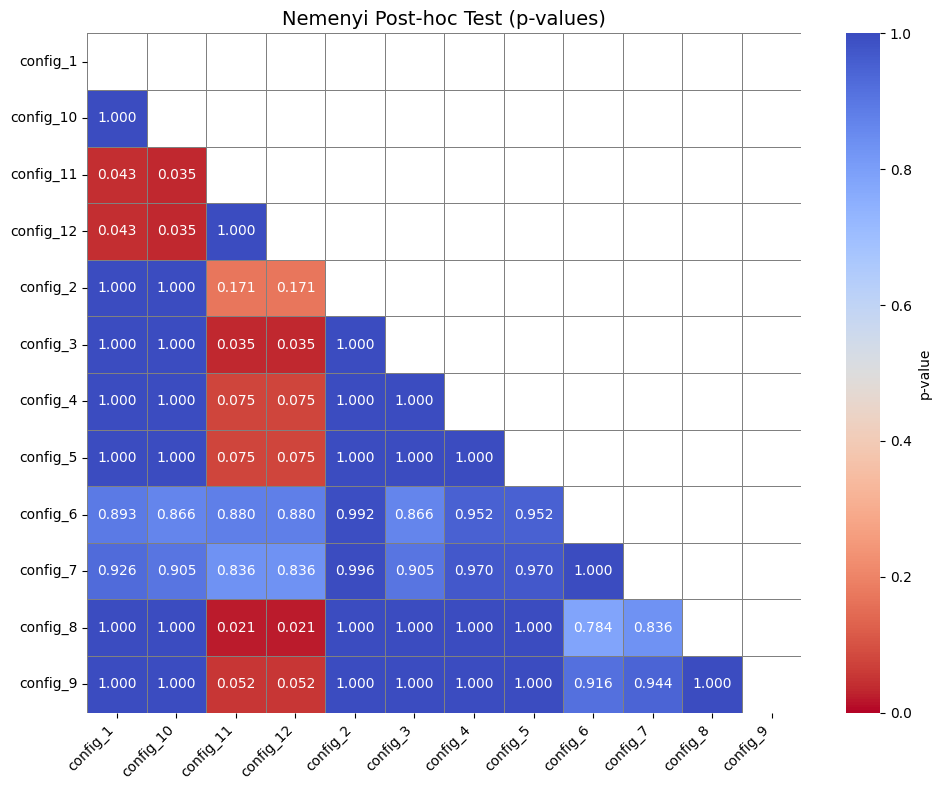

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_nemenyi_heatmap(nemenyi_df):
    plt.figure(figsize=(10, 8))

    # Máscara para esconder diagonal (opcional)
    mask = np.triu(np.ones_like(nemenyi_df, dtype=bool))

    sns.heatmap(
        nemenyi_df,
        annot=True,
        fmt=".3f",
        cmap="coolwarm_r",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor='gray',
        mask=mask,
        cbar_kws={"label": "p-value"}
    )

    plt.title("Nemenyi Post-hoc Test (p-values)", fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()


# Executa
plot_nemenyi_heatmap(nemenyi_results)

O teste de Friedman indicou diferença estatisticamente significativa entre os modelos avaliados (p < 0.001). A análise post-hoc de Nemenyi revelou que as melhores configurações obtidas no grid search formam um grupo de modelos estatisticamente equivalentes entre si, não sendo possível afirmar superioridade de uma configuração específica dentro desse conjunto. Por outro lado, os modelos de controle, incluindo a versão linear e a MLP de baixa complexidade, apresentaram desempenho significativamente inferior, evidenciando a necessidade de modelagem não linear para o problema em questão.

### Analise dos resultados

#### Estabilidade

A estabilidade do processo de treinamento foi avaliada por meio da variabilidade do desempenho entre os diferentes folds da validação cruzada. Para cada configuração, foram consideradas a média e o desvio padrão da acurácia, permitindo quantificar a consistência dos resultados frente a diferentes particionamentos dos dados. Complementarmente, a distribuição das acurácias por fold é apresentada no boxplot a seguir, possibilitando uma análise visual da dispersão e da presença de eventuais outliers.

De modo geral, observa-se que todas as configurações apresentam baixa variabilidade, com desvios padrão em uma faixa bastante próxima, indicando que o processo de treinamento é estável independentemente da configuração utilizada. As melhores configurações distinguem-se principalmente pelo nível de desempenho alcançado, mantendo medianas de acurácia superiores, enquanto os modelos de controle apresentam desempenho inferior de forma consistente ao longo dos folds. As variações observadas são pequenas e não indicam sensibilidade significativa a particionamentos específicos dos dados. Esses resultados sugerem que o problema apresenta comportamento estável sob diferentes divisões, e que as diferenças entre os modelos estão associadas sobretudo à sua capacidade preditiva, e não à variabilidade do processo de treinamento.

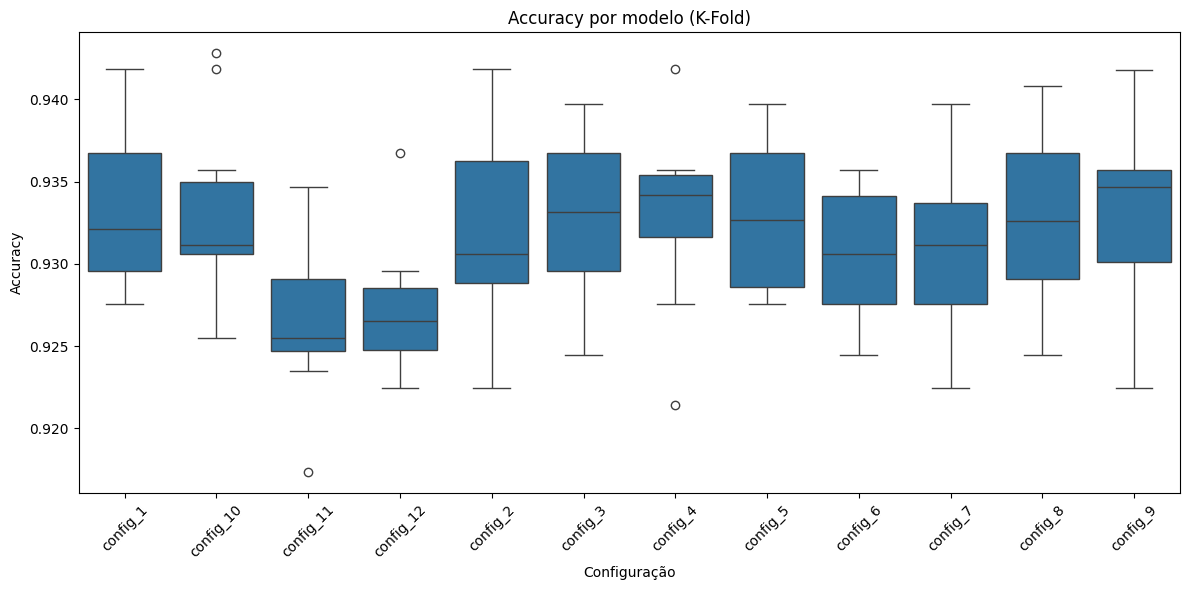

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_kfold_boxplot(df_matrix):
    df_long = df_matrix.reset_index().melt(
        id_vars="fold",
        var_name="config",
        value_name="accuracy_score"
    )

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_long, x="config", y="accuracy_score")

    plt.xticks(rotation=45)
    plt.title("Accuracy por modelo (K-Fold)")
    plt.ylabel("Accuracy")
    plt.xlabel("Configuração")

    plt.tight_layout()
    plt.show()

plot_kfold_boxplot(df_matrix)

#### Convergência

A convergência do treinamento foi avaliada a partir da evolução das métricas ao longo das épocas, bem como pelo comportamento do critério de early stopping. Observa-se que, para a maioria das configurações, o treinamento atinge rapidamente um patamar de desempenho estável, com melhorias marginais após uA análise das curvas de convergência evidencia que todos os modelos apresentam rápida redução da função de perda nas primeiras épocas, indicando eficiência no processo de otimização. No entanto, diferenças claras são observadas no patamar final de convergência. O modelo linear (config_11) converge rapidamente, mas estabiliza em um nível de perda superior, sugerindo limitação de capacidade para capturar padrões mais complexos nos dados. Em contraste, as configurações de melhor desempenho (como config_1 e config_4) continuam reduzindo a função de perda por mais tempo, atingindo valores finais inferiores de forma consistente entre os folds. Observa-se ainda que o mecanismo de early stopping atua de forma semelhante entre os modelos, com a maioria dos folds interrompendo o treinamento entre aproximadamente 30 e 40 épocas, o que indica convergência estável e ausência de sobreajuste significativo. Esses resultados reforçam que o ganho de desempenho dos melhores modelos decorre de sua maior capacidade de representação, e não de diferenças no processo de otimização.m número relativamente reduzido de épocas.

In [47]:
def plot_training_curve(kfold_histories, config_name):
    df = kfold_histories[config_name]

    fig, ax1 = plt.subplots(figsize=(8, 5))

    # ============================
    # Curvas individuais (loss)
    # ============================
    for fold in df["fold"].unique():
        fold_df = df[df["fold"] == fold]
        ax1.plot(fold_df["epoch"], fold_df["val_loss"], alpha=0.3)

    # ============================
    # Estatísticas por época
    # ============================
    stats = df.groupby("epoch")["val_loss"].agg(["mean", "count"])

    # linha da média
    ax1.plot(
        stats.index,
        stats["mean"],
        color="black",
        linewidth=2,
        label="Loss média"
    )

    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss (validação)")

    # ============================
    # Segundo eixo (mesmo gráfico)
    # ============================
    ax2 = ax1.twinx()

    ax2.plot(
        stats.index,
        stats["count"],
        color="red",
        linestyle="--",
        linewidth=2,
        label="Folds ativos"
    )

    ax2.set_ylabel("Folds ativos")

    # ============================
    # Legenda combinada
    # ============================
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()

    ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

    plt.title(f"Convergência - {config_name}")
    plt.tight_layout()
    plt.show()


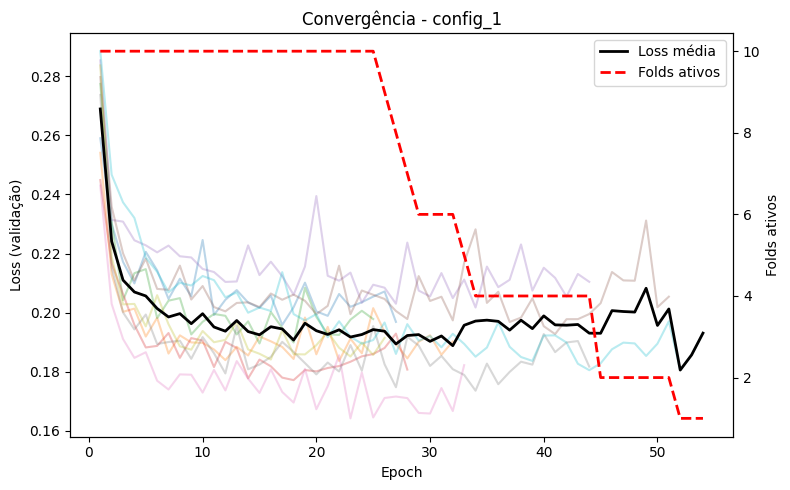

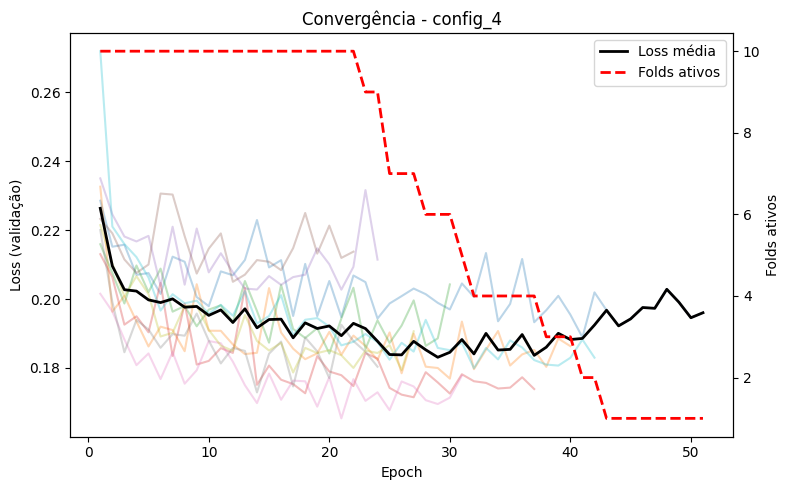

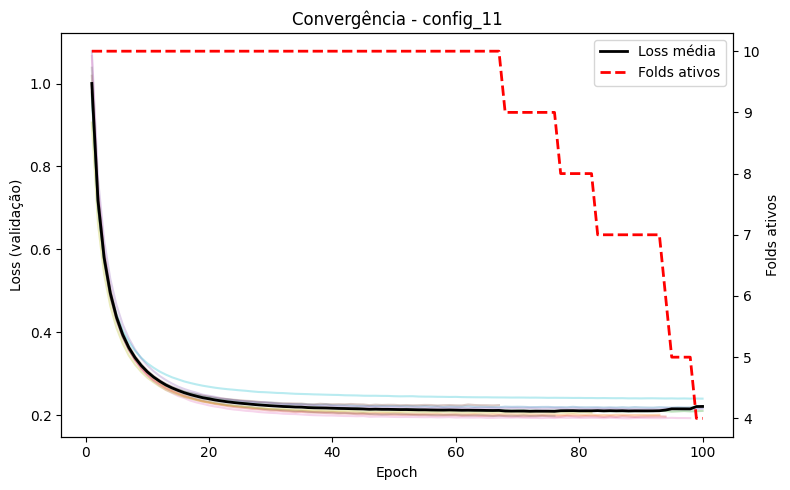

In [49]:
plot_training_curve(kfold_histories, "config_1")
plot_training_curve(kfold_histories, "config_4")
plot_training_curve(kfold_histories, "config_11")

#### Regularização e controle de overfitting

A análise de regularização foi realizada a partir da comparação entre o desempenho nos conjuntos de treino e validação, bem como pela avaliação do impacto de estratégias como dropout, early stopping e weight decay. De forma geral, não foram observados indícios fortes de sobreajuste, uma vez que as métricas de treino e validação permaneceram próximas ao longo do treinamento, ou estes foram controlados de forma eficiente pelo early stopping.

O uso de early stopping mostrou-se eficaz na prevenção de overfitting, interrompendo o treinamento quando não havia melhora significativa na métrica de validação. Adicionalmente, o uso de dropout em algumas configurações contribuiu para reduzir a variabilidade do modelo, embora seus efeitos não tenham sido uniformemente superiores em todos os cenários avaliados. Esses resultados sugerem que o problema apresenta uma complexidade moderada, não exigindo estratégias agressivas de regularização para alcançar bom desempenho.

In [50]:
import matplotlib.pyplot as plt

def plot_train_vs_val_history_with_folds(kfold_histories, kfold_results_df, config_name):
    df = kfold_histories[config_name].copy()

    # médias por época
    mean_df = df.groupby("epoch").agg({
        "train_loss": "mean",
        "val_loss": "mean",
        "train_f1": "mean",
        "val_f1": "mean",
        "train_acc": "mean",
        "val_acc": "mean"
    })

    # folds ativos por época
    folds_per_epoch = df.groupby("epoch")["fold"].nunique()

    # early stopping médio
    best_epoch = kfold_results_df.loc[
        kfold_results_df["config_name"] == config_name,
        "best_epoch"
    ].iloc[0]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ========= Loss =========
    ax = axes[0]
    ax.plot(mean_df.index, mean_df["train_loss"], label="Train")
    ax.plot(mean_df.index, mean_df["val_loss"], label="Validation")
    ax.axvline(best_epoch, linestyle="--", label=f"Early stopping médio ({best_epoch:.1f})")
    ax.set_title(f"Loss média - {config_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")

    ax_folds = ax.twinx()
    ax_folds.plot(
        folds_per_epoch.index,
        folds_per_epoch.values,
        linestyle=":",
        label="Folds ativos"
    )
    ax_folds.set_ylabel("Folds ativos")

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax_folds.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="best")

    # ========= F1 =========
    ax = axes[1]
    ax.plot(mean_df.index, mean_df["train_f1"], label="Train")
    ax.plot(mean_df.index, mean_df["val_f1"], label="Validation")
    ax.axvline(best_epoch, linestyle="--", label=f"Early stopping médio ({best_epoch:.1f})")
    ax.set_title(f"F1 médio - {config_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("F1-score")

    ax_folds = ax.twinx()
    ax_folds.plot(
        folds_per_epoch.index,
        folds_per_epoch.values,
        linestyle=":",
        label="Folds ativos"
    )
    ax_folds.set_ylabel("Folds ativos")

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax_folds.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="best")

    # ========= Accuracy =========
    ax = axes[2]
    ax.plot(mean_df.index, mean_df["train_acc"], label="Train")
    ax.plot(mean_df.index, mean_df["val_acc"], label="Validation")
    ax.axvline(best_epoch, linestyle="--", label=f"Early stopping médio ({best_epoch:.1f})")
    ax.set_title(f"Acurácia média - {config_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")

    ax_folds = ax.twinx()
    ax_folds.plot(
        folds_per_epoch.index,
        folds_per_epoch.values,
        linestyle=":",
        label="Folds ativos"
    )
    ax_folds.set_ylabel("Folds ativos")

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax_folds.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="best")

    plt.tight_layout()
    plt.show()

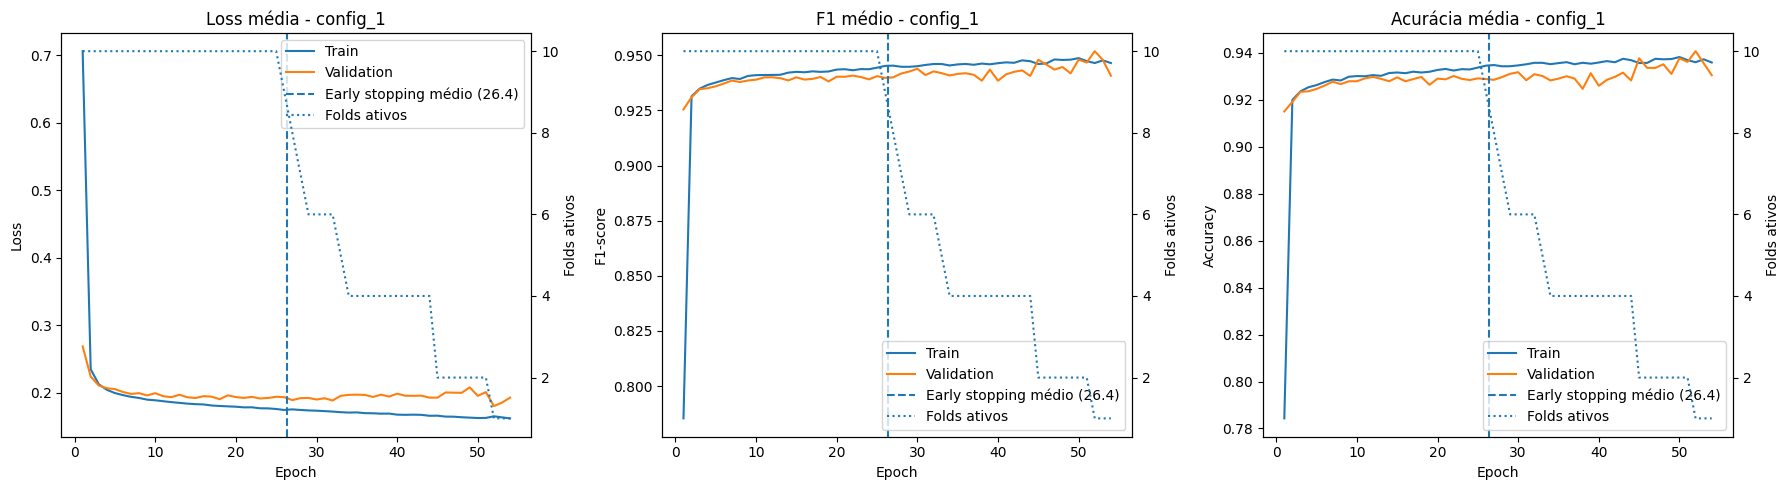

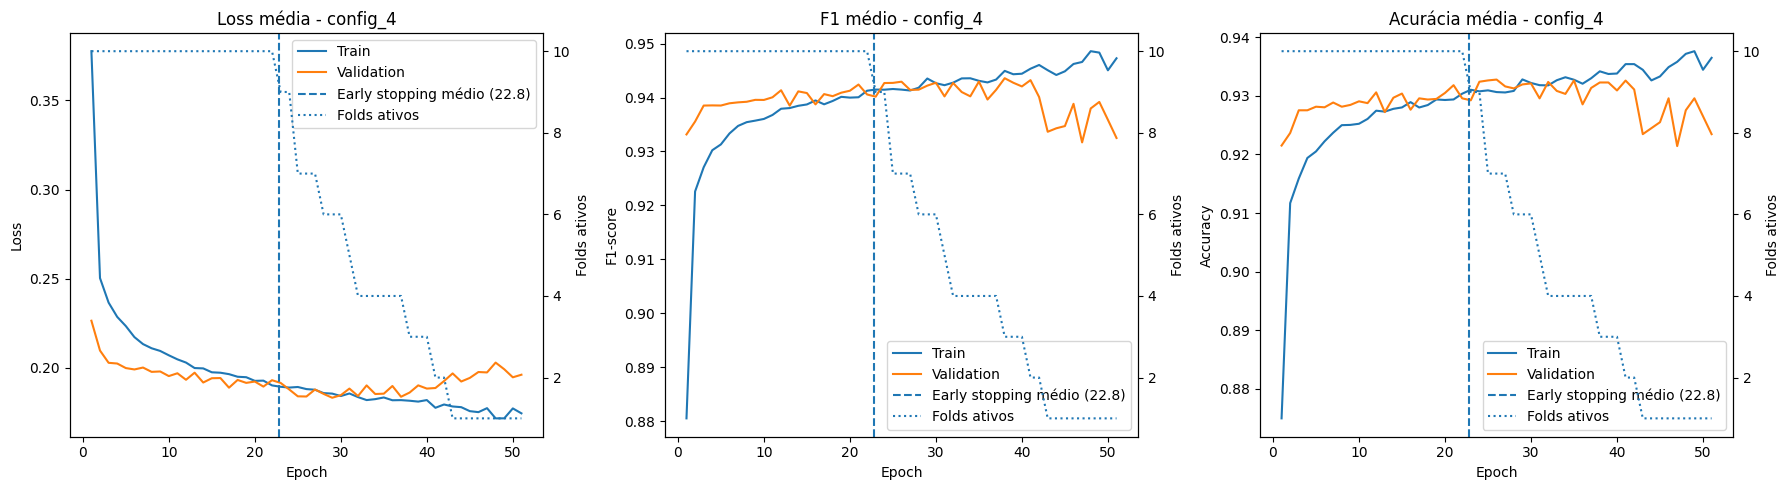

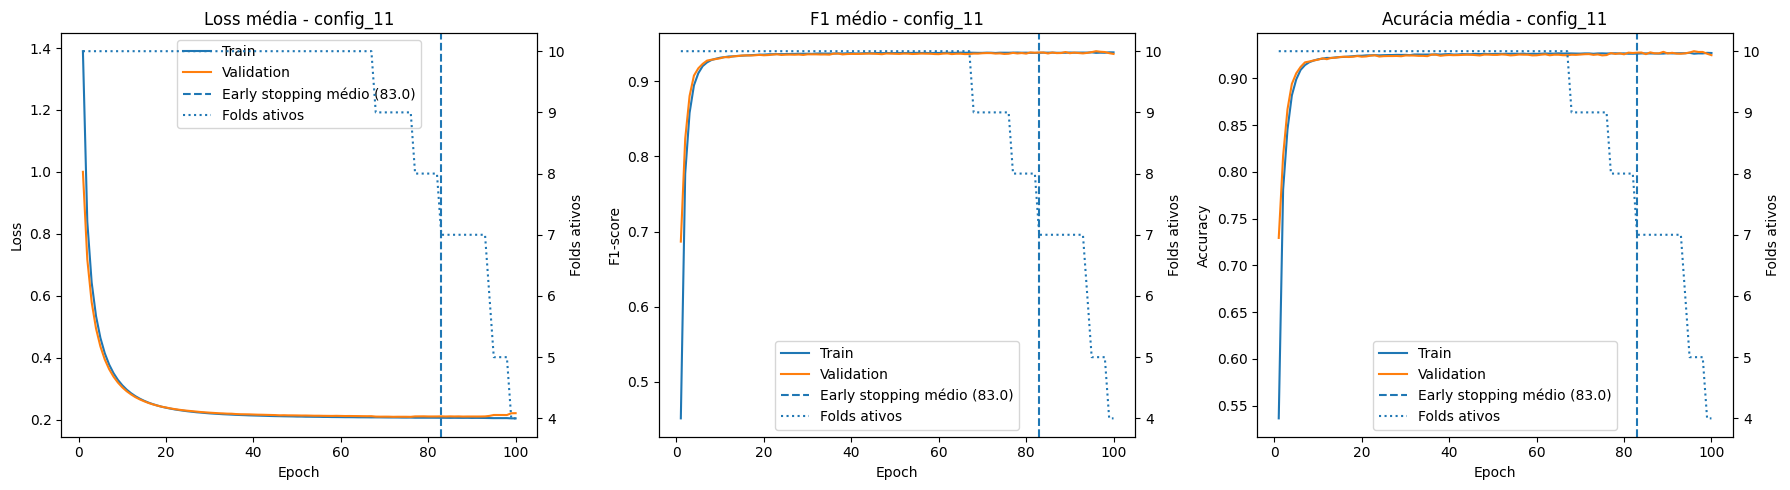

In [53]:
plot_train_vs_val_history_with_folds(
    kfold_histories,
    kfold_results_df,
    "config_1"
)
plot_train_vs_val_history_with_folds(
    kfold_histories,
    kfold_results_df,
    "config_4"
)
plot_train_vs_val_history_with_folds(
    kfold_histories,
    kfold_results_df,
    "config_11"
)

A comparação entre as configurações evidencia comportamentos distintos em termos de capacidade e controle de sobreajuste. A configuração linear (config_11) apresenta curvas de treino e validação praticamente sobrepostas ao longo de todo o treinamento, indicando ausência de overfitting. No entanto, esse comportamento está associado à baixa capacidade do modelo, caracterizando underfitting, uma vez que o desempenho converge rapidamente para um patamar inferior. Em contraste, a configuração mais expressiva (config_4) apresenta um pequeno descolamento entre as curvas de treino e validação, especialmente após as primeiras épocas, indicando o início de um leve sobreajuste. Esse comportamento é esperado em modelos com maior capacidade e é adequadamente controlado pelo mecanismo de early stopping, que interrompe o treinamento no ponto em que a validação deixa de apresentar ganhos consistentes. Dessa forma, observa-se que o melhor desempenho é obtido em um regime de leve overfitting controlado, enquanto a ausência completa de gap, como no modelo linear, está associada à incapacidade de capturar a complexidade dos dados.

#### Impacto do tamanho do batch

A análise do impacto do tamanho do batch sobre o custo e o desempenho dos modelos evidencia um trade-off claro entre tempo de treinamento e acurácia. Observa-se que configurações com batch size igual a 64 apresentam menor tempo de treinamento, concentrando-se na região mais à esquerda do gráfico, enquanto configurações com batch size igual a 32 demandam maior tempo computacional. Em termos de desempenho, no entanto, as diferenças são reduzidas, com leve vantagem para o batch menor, que apresenta valores de acurácia marginalmente superiores. A magnitude desse ganho, contudo, é pequena quando comparada à redução significativa no tempo de treinamento proporcionada pelo batch maior. Esses resultados indicam que o tamanho do batch não altera substancialmente a qualidade das soluções obtidas, mas impacta de forma mais relevante o custo computacional, caracterizando um trade-off entre eficiência e desempenho.

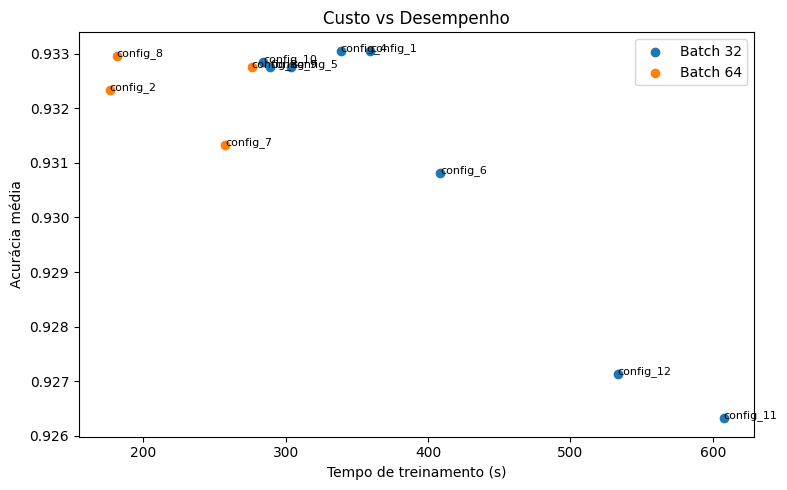

In [58]:
import matplotlib.pyplot as plt

def plot_time_vs_performance(df):
    df = df.loc[:, ~df.columns.duplicated()].copy()

    plt.figure(figsize=(8, 5))

    df_32 = df[df["batch_size"] == 32]
    df_64 = df[df["batch_size"] == 64]

    plt.scatter(
        df_32["training_time_sec"],
        df_32["acc_mean"],
        label="Batch 32"
    )

    plt.scatter(
        df_64["training_time_sec"],
        df_64["acc_mean"],
        label="Batch 64"
    )

    for _, row in df.iterrows():
        plt.text(
            row["training_time_sec"],
            row["acc_mean"],
            row["config_name"],
            fontsize=8
        )

    plt.xlabel("Tempo de treinamento (s)")
    plt.ylabel("Acurácia média")
    plt.title("Custo vs Desempenho")
    plt.legend()

    plt.tight_layout()
    plt.show()


kfold_export = kfold_export.loc[:, ~kfold_export.columns.duplicated()].copy()
plot_time_vs_performance(kfold_export)

## Comparação Estatística

### Avaliação de hipóteses

Com base nos resultados obtidos a partir dos testes de Friedman e Nemenyi, bem como na análise das distribuições de desempenho entre os folds, é possível avaliar as hipóteses propostas:

**Hipótese 1: Modelos não lineares apresentam desempenho superior ao modelo linear — Confirmada.**
O teste de Nemenyi evidenciou que o modelo linear apresenta desempenho estatisticamente inferior em relação às configurações não lineares avaliadas. Essa diferença, embora pequena em termos absolutos, mostrou-se consistente ao longo dos folds e também nas curvas de convergência, nas quais o modelo linear estabiliza em um patamar de perda superior. Esses resultados indicam que a introdução de não-linearidade é necessária para capturar adequadamente a estrutura dos dados, contribuindo de forma efetiva para a melhoria do desempenho.

**Hipótese 2: O aumento da complexidade do modelo gera ganhos marginais de desempenho — Confirmada.**
Embora arquiteturas mais complexas apresentem, em média, valores ligeiramente superiores de desempenho, o teste de Nemenyi não identificou diferenças estatisticamente significativas entre a maioria das configurações não lineares. Adicionalmente, a análise de estabilidade mostrou que esses modelos apresentam comportamento semelhante entre os folds. Isso indica que o aumento da complexidade tende a produzir apenas ganhos marginais, sem impacto significativo do ponto de vista estatístico.

**Hipótese 3: Modelos mais simples podem apresentar melhor relação custo-benefício — Parcialmente confirmada.**
A análise conjunta de desempenho e custo computacional indica que modelos mais simples, dentro do grupo de arquiteturas não lineares, podem alcançar desempenho estatisticamente equivalente aos modelos mais complexos, com menor tempo de treinamento. No entanto, modelos excessivamente simples, como o modelo linear e a MLP de baixa capacidade, apresentaram desempenho significativamente inferior, o que limita a validade dessa hipótese de forma geral. Dessa forma, a relação custo-benefício mais favorável ocorre em configurações intermediárias, e não nos modelos mais simples possíveis.

**Hipótese 4: O tamanho do batch impacta o custo computacional mais do que o desempenho — Confirmada.**
A análise do gráfico de custo versus desempenho evidenciou que o aumento do batch size reduz de forma consistente o tempo de treinamento, sem provocar alterações relevantes no desempenho preditivo. As diferenças de acurácia observadas entre batches são pequenas e não alteram o agrupamento estatístico dos modelos identificado pelo teste de Nemenyi. Esses resultados indicam que o tamanho do batch exerce impacto predominante sobre o custo computacional, enquanto seu efeito sobre o desempenho é secundário.

## Testando o modelo

### A escolha do modelo

A seleção do modelo final foi realizada com base no desempenho preditivo observado durante a validação cruzada, considerando como critério principal a **acurácia média**, em alinhamento com a métrica adotada na avaliação estatística. Como os recursos computacionais disponíveis e o tempo de treinamento não constituem restrições relevantes neste contexto, optou-se por priorizar o modelo com melhor desempenho geral, utilizando a variabilidade entre folds como critério secundário de desempate.

Os resultados do teste de Friedman indicaram diferenças estatisticamente significativas entre os modelos avaliados, enquanto a análise post-hoc de Nemenyi evidenciou que as melhores configurações pertencem a um grupo de modelos estatisticamente equivalentes. Dessa forma, não é possível afirmar a superioridade estatística de uma única configuração dentro desse grupo.

Ainda assim, entre essas configurações, o modelo **config_1** apresentou o maior valor de acurácia média, aliado a menor variabilidade entre os folds e melhor desempenho nos cenários mais desafiadores, sendo, portanto, selecionado como modelo final.

Essa escolha reflete uma estratégia orientada à maximização de desempenho dentro de um conjunto de soluções equivalentes, na qual pequenas diferenças de desempenho e estabilidade são consideradas relevantes na ausência de restrições práticas. Ao mesmo tempo, a decisão permanece consistente com os resultados estatísticos, uma vez que o modelo selecionado pertence ao grupo de melhor desempenho identificado pelos testes aplicados.

### Treinamento final do modelo

Após a seleção do modelo com base nos resultados da validação cruzada, o treinamento final é realizado utilizando todo o conjunto de dados de treinamento disponível. Essa abordagem permite que o modelo aproveite ao máximo as informações presentes nos dados, uma vez que não há mais necessidade de separação para validação interna, dado que a escolha da configuração já foi concluída.

O modelo resultante será então utilizado para avaliação no conjunto de teste, fornecendo uma estimativa final de seu desempenho em dados não vistos.

Definimos inicialmente uma função para o treinamento final. Ela é ligeiramente diferente das outras duas por que não precisa se preocupar com validação ou early stopping. Compilamos o historico das metricas e da loss apenas para verificação de consistencia. E também exportamos o standard scaler utilizado para normalizar os dados.

In [59]:
def train_final_model(
    X,
    y,
    config,
    input_dim,
    output_dim,
    device,
    epochs=None
):
    # número de épocas do treinamento final
    final_epochs = epochs if epochs is not None else config.epochs

    # normalização usando todo o conjunto informado
    scaler = StandardScaler()
    X_normal = scaler.fit_transform(X).astype("float32")

    # codificação das classes
    class_names = sorted(y.unique())
    class_to_index = {label: idx for idx, label in enumerate(class_names)}
    index_to_class = {idx: label for label, idx in class_to_index.items()}

    y_encoded = y.map(class_to_index).to_numpy()

    # dataset completo
    X_tensor = torch.tensor(X_normal, dtype=torch.float32)
    y_tensor = torch.tensor(y_encoded, dtype=torch.long)

    dataset = TensorDataset(X_tensor, y_tensor)

    dataloader = DataLoader(
        dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=0
    )

    # modelo
    model = ConfigurableMLP(
        input_dim=input_dim,
        output_dim=output_dim,
        config=config
    ).to(device)

    optimizer = build_optimizer(model, config)
    criterion = torch.nn.CrossEntropyLoss()

    history = []

    epoch_progress = tqdm(range(final_epochs), desc="Treinamento final")

    for epoch in epoch_progress:
        model.train()

        train_losses = []
        y_true_train = []
        y_pred_train = []

        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            preds = torch.argmax(outputs, dim=1)

            train_losses.append(loss.item())
            y_true_train.extend(y_batch.cpu().numpy())
            y_pred_train.extend(preds.cpu().numpy())

        train_loss = float(np.mean(train_losses))
        train_f1 = f1_score(y_true_train, y_pred_train, average="macro")
        train_acc = accuracy_score(y_true_train, y_pred_train)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_f1": train_f1,
            "train_acc": train_acc
        })

        epoch_progress.set_postfix({
            "loss": f"{train_loss:.4f}",
            "f1": f"{train_f1:.4f}",
            "acc": f"{train_acc:.4f}"
        })

    history_df = pd.DataFrame(history)

    return model, history_df, scaler, class_to_index, index_to_class

Aplicamos o treinamento sobre todo o conjunto disponível de dados rotulados. Nessa etapa, não é possível utilizar o mecanismo de early stopping, uma vez que não há um conjunto de validação separado para monitorar o desempenho durante o treinamento. Para contornar essa limitação, utilizamos a média das épocas de melhor desempenho observadas durante a validação cruzada como referência para definir o número de épocas do treinamento final. Dessa forma, o modelo é treinado por um número de épocas consistente com o comportamento observado anteriormente, evitando tanto o subtreinamento quanto o prolongamento desnecessário do processo de otimização.

In [ ]:
# seleciona a melhor configuração
best_config = kfold_results_df.loc[
    kfold_results_df["config_name"] == "config_1",
    "config"
].iloc[0]

# calcula a média de épocas do melhor desempenho de cada fold
best_epochs = round(
    kfold_results_df.loc[
        kfold_results_df["config_name"] == "config_1",
        "best_epoch"
    ].iloc[0]
)

# treina o modelo final
final_model, final_history_df, final_scaler, class_to_index, index_to_class = train_final_model(
    X=X_train,
    y=y_train,
    config=best_config,
    input_dim=X_train.shape[1],
    output_dim=y_train.nunique(),
    device=device,
    epochs=best_epochs
)

Treinamento final:   0%|          | 0/26 [00:00<?, ?it/s]

In [64]:
def plot_final_training_history(history_df, best_epoch=None, config_name=None):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    title_suffix = f" - {config_name}" if config_name else ""

    # ========= Loss =========
    ax = axes[0]
    ax.plot(
        history_df["epoch"],
        history_df["train_loss"],
        linewidth=2,
        marker="o",
        markersize=3,
        label="Train"
    )

    if best_epoch:
        ax.axvline(
            best_epoch,
            linestyle="--",
            label=f"Epoch de referência ({best_epoch})"
        )

    ax.set_title(f"Loss{title_suffix}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)
    ax.legend()

    # ========= F1 =========
    ax = axes[1]
    ax.plot(
        history_df["epoch"],
        history_df["train_f1"],
        linewidth=2,
        marker="o",
        markersize=3,
        label="Train"
    )

    if best_epoch:
        ax.axvline(
            best_epoch,
            linestyle="--",
            label=f"Epoch de referência ({best_epoch})"
        )

    ax.set_title(f"F1-score{title_suffix}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("F1")
    ax.grid(alpha=0.3)
    ax.legend()

    # ========= Accuracy =========
    ax = axes[2]
    ax.plot(
        history_df["epoch"],
        history_df["train_acc"],
        linewidth=2,
        marker="o",
        markersize=3,
        label="Train"
    )

    if best_epoch:
        ax.axvline(
            best_epoch,
            linestyle="--",
            label=f"Epoch de referência ({best_epoch})"
        )

    ax.set_title(f"Acurácia{title_suffix}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

Registramos Loss, F1 e Acurácia.

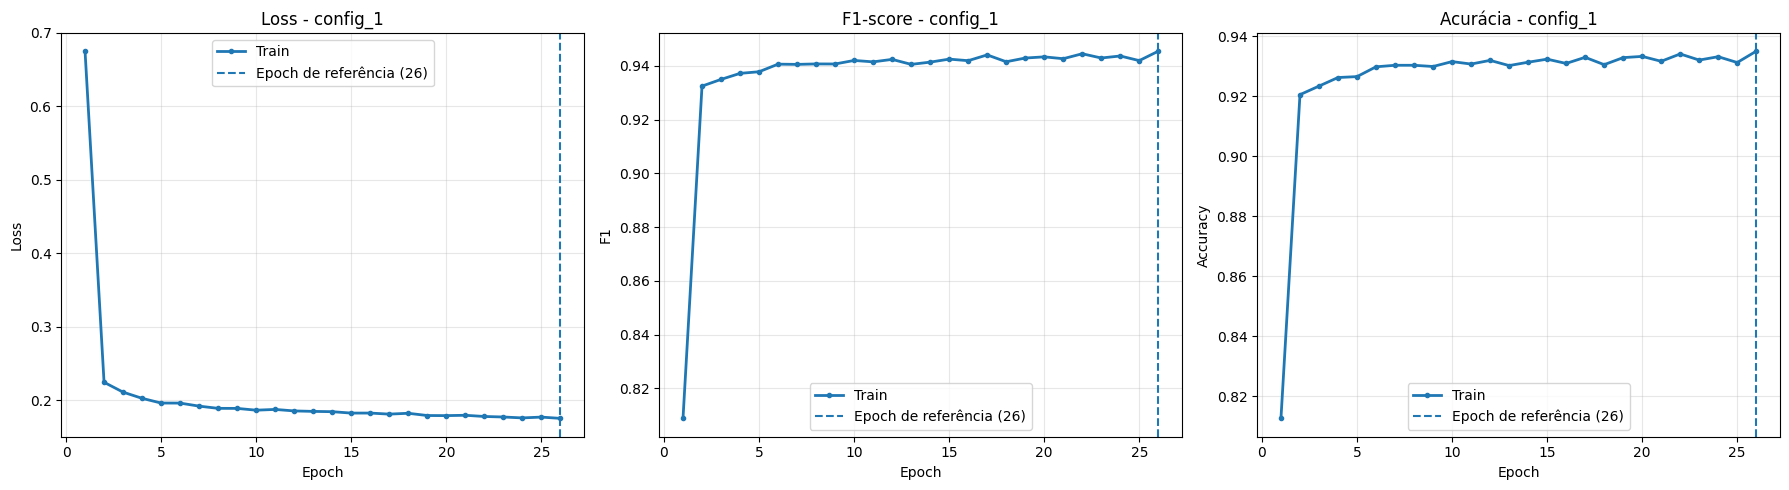

In [65]:
plot_final_training_history(
    history_df=final_history_df,
    best_epoch=best_epochs,
    config_name="config_1"
)

Definimos a função de inferencia que será utilizada para testar o modelo escolhido.

In [66]:
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

def run_inference(
    model,
    X,
    y,
    scaler,
    class_to_index,
    index_to_class,
    device,
    batch_size=128
):
    # coloca o modelo em modo de avaliação
    model.eval()

    # aplica a mesma normalização do treino final
    X_normal = scaler.transform(X).astype("float32")

    # codificação dos rótulos reais
    y_encoded = y.map(class_to_index).to_numpy()

    # tensor e dataloader
    X_tensor = torch.tensor(X_normal, dtype=torch.float32)
    y_tensor = torch.tensor(y_encoded, dtype=torch.long)

    dataset = TensorDataset(X_tensor, y_tensor)

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for X_batch, y_batch in tqdm(dataloader, desc="Inferência"):
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    # converte predições para nomes de classes
    y_true_labels = [index_to_class[idx] for idx in y_true]
    y_pred_labels = [index_to_class[idx] for idx in y_pred]

    # métricas
    results = {
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "recall_macro": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "confusion_matrix": confusion_matrix(y_true, y_pred)
    }

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_true_labels": y_true_labels,
        "y_pred_labels": y_pred_labels,
        "y_prob": np.array(y_prob),
        "metrics": results
    }

Executamos a inferencia utilizando o conjunto de teste.

In [67]:
test_results = run_inference(
    model=final_model,
    X=X_test,
    y=y_test,
    scaler=final_scaler,
    class_to_index=class_to_index,
    index_to_class=index_to_class,
    device=device,
    batch_size=best_config.batch_size
)

print(f"F1 macro.......: {test_results['metrics']['f1_macro']:.4f}")
print(f"F1 weighted....: {test_results['metrics']['f1_weighted']:.4f}")
print(f"Accuracy.......: {test_results['metrics']['accuracy']:.4f}")
print(f"Precision macro: {test_results['metrics']['precision_macro']:.4f}")
print(f"Recall macro...: {test_results['metrics']['recall_macro']:.4f}")


Inferência:   0%|          | 0/35 [00:00<?, ?it/s]

F1 macro.......: 0.9333
F1 weighted....: 0.9256
Accuracy.......: 0.9256
Precision macro: 0.9336
Recall macro...: 0.9331


No conjunto de teste isolado, não utilizado durante a seleção de hiperparâmetros nem durante a validação cruzada, o modelo final obteve acurácia de 0,9256, F1 macro de 0,9333 e F1 ponderado de 0,9256. Esses resultados indicam desempenho consistente com a etapa de validação, embora ligeiramente inferior à média observada no k-fold, o que é esperado em uma avaliação final sobre dados completamente não vistos. A proximidade entre precision macro e recall macro sugere desempenho equilibrado entre as classes, sem predominância clara de erros de precisão ou de revocação.

Preparamos a exibição gráfica da matriz de confusão.

In [72]:
def plot_confusion_matrix(cm, class_to_index, normalize=False):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np

    index_to_class = {idx: label for label, idx in class_to_index.items()}

    sorted_indices = sorted(index_to_class.keys())
    labels = [f"{index_to_class[i]} ({i})" for i in sorted_indices]

    if normalize:
        cm_to_plot = cm.astype(float)
        cm_to_plot = cm_to_plot / cm_to_plot.sum(axis=1, keepdims=True)
        fmt = ".2f"
        title = "Matriz de Confusão (Normalizada)"
    else:
        cm_to_plot = cm.astype(int)
        fmt = "d"
        title = "Matriz de Confusão"

    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm_to_plot,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

E exibimos a matrix de confusão gerada a partir da inferência.

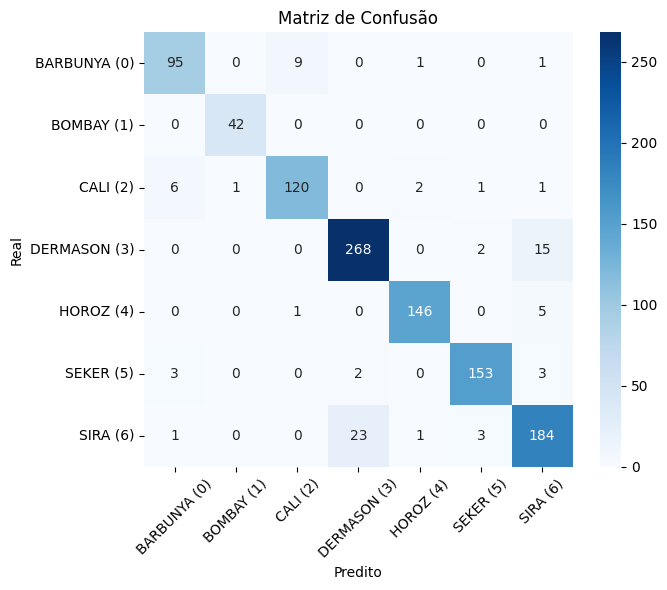

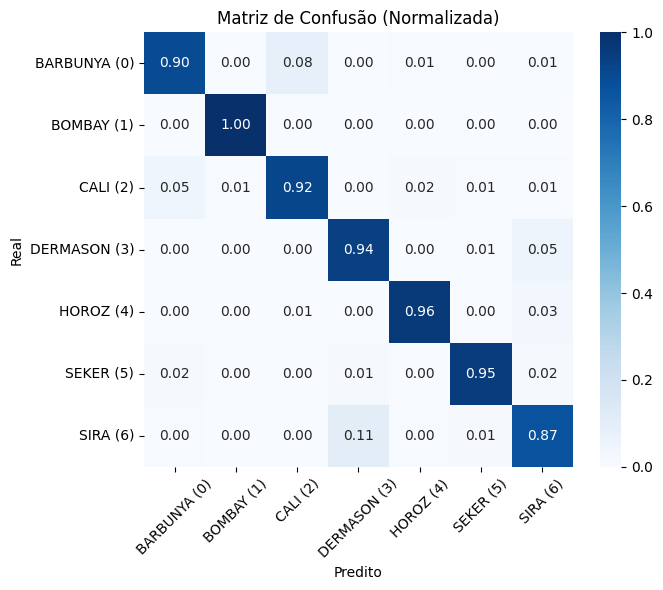

In [73]:
# absoluta
plot_confusion_matrix(
    test_results["metrics"]["confusion_matrix"],
    class_to_index,
    normalize=False
)

# normalizada (recomendado para análise)
plot_confusion_matrix(
    test_results["metrics"]["confusion_matrix"],
    class_to_index,
    normalize=True
)

A matriz de confusão evidencia que o modelo apresenta desempenho elevado na maioria das classes, com forte predominância de acertos na diagonal principal. Algumas classes, como BOMBAY, são perfeitamente classificadas, enquanto outras, como HOROZ e SEKER, também apresentam taxas de acerto superiores a 95%. As principais confusões ocorrem entre pares específicos de classes, destacando-se a relação entre BARBUNYA e CALI, bem como entre SIRA e DERMASON. Esses erros apresentam padrão consistente e não aleatório, sugerindo sobreposição no espaço de características dessas classes. Em particular, a classe SIRA apresenta o menor desempenho, sendo frequentemente confundida com DERMASON, o que indica maior dificuldade do modelo em distinguir essas categorias. De forma geral, os resultados mostram que o modelo é capaz de capturar adequadamente a estrutura do problema, com erros concentrados em regiões específicas de maior complexidade.

## Conclusões

Os resultados obtidos neste estudo permitem extrair conclusões consistentes acerca do impacto da complexidade do modelo e de seus hiperparâmetros no desempenho da tarefa de classificação. A análise estatística, conduzida por meio do teste de Friedman seguido do teste post-hoc de Nemenyi, indicou a existência de diferenças estatisticamente significativas entre os modelos avaliados. Em particular, verificou-se que o modelo linear apresentou desempenho inferior de forma consistente, tanto nas métricas agregadas quanto na análise de convergência, confirmando que a introdução de não-linearidade é fundamental para capturar adequadamente a estrutura dos dados.

Por outro lado, não foram observadas diferenças estatisticamente significativas entre as melhores arquiteturas não lineares, mesmo quando comparadas configurações com diferentes níveis de complexidade. A análise de estabilidade e das curvas de convergência mostrou que esses modelos apresentam comportamento semelhante ao longo dos folds, indicando que o aumento da capacidade do modelo resulta apenas em ganhos marginais de desempenho. Esses resultados sugerem que arquiteturas de complexidade moderada são suficientes para atingir o melhor desempenho possível no problema, sem necessidade de estruturas mais profundas ou sofisticadas.

A análise conjunta de desempenho e custo computacional evidenciou um trade-off claro entre tempo de treinamento e acurácia. Modelos com batch size maior apresentaram redução significativa no tempo de treinamento, enquanto o impacto sobre o desempenho foi pequeno e não alterou o agrupamento estatístico dos modelos identificado pelo teste de Nemenyi. Isso indica que o tamanho do batch influencia predominantemente o custo computacional, sendo um parâmetro de ajuste prático, mas de impacto secundário na qualidade das predições.

A avaliação no conjunto de teste independente confirmou a capacidade de generalização do modelo selecionado, com desempenho consistente em relação aos resultados obtidos na validação cruzada. A análise da matriz de confusão revelou que o modelo apresenta alto desempenho na maioria das classes, com erros concentrados em pares específicos, como BARBUNYA e CALI, e principalmente entre SIRA e DERMASON. Esses padrões de erro não são aleatórios e sugerem sobreposição no espaço de características dessas classes, indicando que as limitações observadas estão mais relacionadas à representatividade dos atributos do que à capacidade do modelo.

Em conjunto, os resultados indicam que a escolha de modelos para este problema deve priorizar arquiteturas não lineares de complexidade moderada, que apresentam desempenho elevado, estabilidade entre diferentes particionamentos dos dados e boa capacidade de generalização, ao mesmo tempo em que mantêm eficiência computacional adequada.

## Resolução da competição/desafio

Para a resolução do desafio proposto, o modelo final será treinado utilizando a totalidade dos dados rotulados disponíveis, sem a separação de um conjunto de validação adicional. Nessa etapa, o mecanismo de early stopping não pôde ser aplicado diretamente, sendo o número de épocas definido com base na média das melhores épocas observadas durante a validação cruzada. Após o treinamento, o modelo será utilizado para realizar inferência sobre o conjunto de dados sem rótulos fornecido, aplicando-se o mesmo processo de normalização aprendido no treinamento. As predições geradas constituem a saída final submetida para avaliação no contexto da competição.

In [75]:
def run_inference_unlabeled(model, X, scaler, index_to_class, device, batch_size=128):
    model.eval()

    X_normal = scaler.transform(X).astype("float32")

    X_tensor = torch.tensor(X_normal, dtype=torch.float32)

    dataloader = DataLoader(
        X_tensor,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    y_pred = []
    y_prob = []

    with torch.no_grad():
        for X_batch in tqdm(dataloader, desc="Inferência (sem label)"):
            X_batch = X_batch.to(device)

            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    # converte para labels
    y_pred_labels = [index_to_class[idx] for idx in y_pred]

    return {
        "y_pred": y_pred,
        "y_pred_labels": y_pred_labels,
        "y_prob": np.array(y_prob)
    }

In [ ]:
challenge_model, challenge_history_df, challenge_scaler, challenge_class_to_index, challenge_index_to_class = train_final_model(
    X=X,
    y=y,
    config=best_config,
    input_dim=X.shape[1],
    output_dim=y.nunique(),
    device=device,
    epochs=best_epochs
)

Treinamento final:   0%|          | 0/26 [00:00<?, ?it/s]

In [79]:
df_unlabeled = pd.read_csv("beans_test.csv")
X_unlabeled = df_unlabeled.copy()

# Inferência
challenge_results = run_inference_unlabeled(
    model=challenge_model,
    X=X_unlabeled,
    scaler=challenge_scaler,
    index_to_class=challenge_index_to_class,
    device=device,
    batch_size=best_config.batch_size
)

# Se sua função retorna dict
challenge_predictions = challenge_results["y_pred_labels"]

df_submission = pd.DataFrame({
    "Class": challenge_predictions
})

df_submission.to_csv("submission.csv", index=False)

print(df_submission.head())
print(df_submission.shape)

Inferência (sem label):   0%|          | 0/86 [00:00<?, ?it/s]

      Class
0     SEKER
1     SEKER
2     HOROZ
3  BARBUNYA
4      CALI
(2723, 1)
